# Classification Evaluation — LoTSS

Evaluates self-supervised and supervised model representations on the LoTSS downstream classification task.
The **evaluation label set** is controlled by `CONFIG["eval_label_set"]`.
The **confusion matrix** (Section 8) uses `CM_CONFIG["eval_label_set"]` (default: `initial_pure`, 5-class multiclass).

All configurations (`CONFIG`, `GRID_CONFIG`, `CM_CONFIG`) are defined in Section 0. All imports are in Section 1.

Sections:
- **0** Configuration
- **1** Imports & Setup
- **2** Load Representations
- **3** Downstream Classifiers
- **4** Supervised Baseline Comparison
- **5** Fine-tuning Comparison
- **6** Label Fraction
- **7** Hyperparameter Sweep
- **8** Confusion Matrix
- **9** Generative Augmentation

## 0. Configuration

Edit `CONFIG` to point to the target checkpoint and set output paths.
`GRID_CONFIG` controls the hyperparameter sweep axes (Section 7).
`CM_CONFIG` controls which classifiers appear in the confusion matrix (Section 8).

In [54]:
CONFIG = {
    # ── Main BYOL run ──────────────────────────────────────────────────────────
    "checkpoint":    "../outputs/byol_runs/enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f1_sw0.05_augquart_ext_20260709_2203/byol_model_best.pt",
    "catalogue":     "../catalogues/lotss_initial_all.yaml",
    "colour_by":     "dataset",   # "dataset" | "label"
    "root":          "..",

    # ── Label sets & classifier settings ───────────────────────────────────────
    "train_label_set": 'full', # initial | morphology | environment | classical | initial_pure
    "class_weight":    "all", #all | initial | morphology | environment | classical | "" (no weighting)
    "early_stopping":  False,
    "eval_label_set": "initial",
 
    # ── Supervised baselines (Section 4) ──────────────────────────────────────
    "baselines_dir": "../outputs/supervised_baseline_classifiers",

    # ── Fine-tuning runs (Sections 5, 6, 8) ───────────────────────────────────
    # Section 5 shows ALL finetuning dirs matching train_label_set + class_weight.
    # Section 8 uses the one whose mode/lr/epochs match finetuning_spec.
    "finetuning_runs": [
        "../outputs/byol_runs/enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f1_sw0.05_augquart_ext_20260709_2203/",
    ],
    "finetuning_spec": "mode2_lr1e-5_ep40",             # mode2: frozen encoder, fine-tune projector + head
    "finetuning_spec_retrained": "mode3_lr1e-5_ep40",   # mode3: full encoder retrain (Section 6)

    # ── BYOL runs root (Section 6) ────────────────────────────────────────────
    "byol_runs_dir": "../outputs/byol_runs",
}

# ── Hyperparameter sweep (Section 7) ──────────────────────────────────────────
GRID_CONFIG = {
    "axis_x":        "f",            # label fraction  (f0, f0.1, f0.5, f1 …)
    "axis_y":        "sw",           # supervision wt  (sw0.01, sw0.1, sw1 …)
    "classifier":    "rf",           # rf | knn | lr
    "feature_type":  "projections",
    "outputs_root":  "../outputs/byol_runs",
    "run_glob":      "enb0_*",
}

# ── Confusion matrix (Section 8) ──────────────────────────────────────────────
# The confusion matrix always uses initial_pure (5-class multiclass) regardless
# of CONFIG["eval_label_set"].
CM_CONFIG = {
    "eval_label_set":  "initial_pure",
    "byol_classifier": "linear_probe",   # "random_forest" | "knn" | "linear_probe"
    "baseline_model":  "enb0",           # substring matched against baseline run dir names
    "n_estimators":    200,
    "n_neighbors":     15,
}

OUT_DIR = "../outputs/figures/classification"
SEED    = 42

## 1. Imports & Setup

All third-party imports and project-local imports (`load_encoder`, `ALL_CLASS_NAMES`, `LABEL_SETS`).
`OUT_DIR` is created here if it does not exist.

In [55]:
import os, sys, re
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import torch
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score, confusion_matrix

# Add project src and scripts to path
_root = os.path.abspath("..")
for _p in [os.path.join(_root, "src"), os.path.join(_root, "scripts")]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

from embed_and_umap import load_encoder
from train_byol_classifiers import ALL_CLASS_NAMES, LABEL_SETS

os.makedirs(OUT_DIR, exist_ok=True)
print("Imports OK")

Imports OK


## 2. Load Representations

Loads the checkpoint and extracts projections for downstream evaluation.

**Encoder:** Loads the checkpoint and returns the online encoder + projector. Model type is auto-detected from the run's configuration log.

**Projections:** Loads pre-extracted projections from the run's `data/` directory, ensuring the train/test split matches what `train_byol_classifiers.py` uses.

`projs_cache[cache_key]` contains:
- `projs`     — shape `(N, proj_dim)`
- `labels`    — shape `(N,)` int64, argmax over the configured label set
- `split_ids` — shape `(N,)` int64, 0=train / 2=test

In [56]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

encoder, projector = load_encoder(CONFIG["checkpoint"], device)
encoder.eval()
projector.eval()

# Detect dimensions via dummy forward pass
with torch.no_grad():
    _dummy   = torch.zeros(1, 1, 89, 89).to(device)
    enc_dim  = encoder(_dummy).shape[-1]
    proj_dim = projector(encoder(_dummy)).shape[-1]

print(f"\nEncoder output dim  : {enc_dim}")
print(f"Projector output dim: {proj_dim}")


Device: cuda
Loading checkpoint: ../outputs/byol_runs/enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f1_sw0.05_augquart_ext_20260709_2203/byol_model_best.pt
  Model type: efficientnet-b0
  Feature compression: mlp
  Projector output dim: 128

Encoder output dim  : 1280
Projector output dim: 128


In [57]:
projs_cache = {}

_run_dir  = Path(CONFIG["checkpoint"]).parent
_data_dir = _run_dir / "data"
_byol_dir = _data_dir / "byol"

# Derive shared splits directory from the checkpoint's data_seed.
# Layout: outputs/byol_runs/<run>/  →  outputs/data_splits/<seed>/
_ckpt_raw   = torch.load(CONFIG["checkpoint"], map_location="cpu", weights_only=False)
_data_seed  = int(_ckpt_raw["config"]["data_seed"])
_splits_dir = _run_dir.parent.parent / "data_splits" / str(_data_seed)

def _load_label(name):
    """Load a label .npy from splits_dir (new runs) or data_dir (old runs)."""
    p = _splits_dir / name
    return np.load(p if p.exists() else _data_dir / name)

_X_train = np.load(_byol_dir / "labelled_train_projections.npy").astype(np.float32)
_X_test  = np.load(_byol_dir / "test_projections.npy").astype(np.float32)

_lab_labels_path = _splits_dir / "labelled_train_labels.npy"
if not _lab_labels_path.exists():
    _lab_labels_path = _data_dir / "labelled_train_labels.npy"
if _lab_labels_path.exists():
    _y_train_20 = np.load(_lab_labels_path)
    if len(_y_train_20) != len(_X_train):
        # labelled_train_labels.npy was written by a different f_label run.
        # Reconstruct by concatenating labelled + unlabelled labels (covers all of
        # train_idx in order, which matches labelled_train_projections.npy for f=1).
        _unlab_lbl = _splits_dir / "unlabelled_train_labels.npy"
        if not _unlab_lbl.exists():
            _unlab_lbl = _data_dir / "unlabelled_train_labels.npy"
        if _unlab_lbl.exists():
            _y_train_20 = np.concatenate([_y_train_20, np.load(_unlab_lbl)])
        if len(_y_train_20) != len(_X_train):
            raise ValueError(f"Label count {len(_y_train_20)} != projection count {len(_X_train)}")
else:
    _all_train = _load_label("train_labels.npy")
    _lab_idx   = _load_label("labelled_train_idx.npy")
    _y_train_20 = _all_train if len(_all_train) == len(_X_train) else _all_train[_lab_idx]
_y_test_20 = _load_label("test_labels.npy")

def _initial_pure_mask(y20):
    """Rows with exactly one label among the 5 initial classes (FRI/FRII/Hybrid/Spiral/Relaxed)."""
    return y20[:, 0:5].sum(axis=1) == 1

_tr_mask = _initial_pure_mask(_y_train_20)
_te_mask = _initial_pure_mask(_y_test_20)

_X_tr_cp = _X_train[_tr_mask]
_y_tr_cp = _y_train_20[_tr_mask][:, 0:5].argmax(axis=1).astype(np.int64)
_X_te_cp = _X_test[_te_mask]
_y_te_cp = _y_test_20[_te_mask][:, 0:5].argmax(axis=1).astype(np.int64)

projs_cache["lotss_initial_pure"] = {
    "projs":     np.concatenate([_X_tr_cp, _X_te_cp]),
    "labels":    np.concatenate([_y_tr_cp, _y_te_cp]),
    "split_ids": np.concatenate([
        np.zeros(len(_X_tr_cp), dtype=np.int64),
        np.full(len(_X_te_cp), 2, dtype=np.int64),
    ]),
}
print(f"splits_dir : {_splits_dir}")
print(f"Loaded lotss_initial_pure: train={len(_X_tr_cp)}  test={len(_X_te_cp)}  proj_dim={_X_tr_cp.shape[1]}")

# ── Also load the eval label set (if different from initial_pure) ─────────────
_eval_ls = CONFIG.get("eval_label_set", "full")
if _eval_ls != "initial_pure":
    _eval_cols = LABEL_SETS[_eval_ls]
    _y_tr_ev   = _y_train_20[:, _eval_cols]
    _y_te_ev   = _y_test_20[:, _eval_cols]
    _PURE_ELS_CACHE = {"classical_pure", "morphology_pure", "environment_pure", "full_pure"}
    if _eval_ls in _PURE_ELS_CACHE:
        _pm_tr = _y_tr_ev.sum(axis=1) == 1
        _pm_te = _y_te_ev.sum(axis=1) == 1
        projs_cache[f"lotss_{_eval_ls}"] = {
            "projs":     np.concatenate([_X_train[_pm_tr], _X_test[_pm_te]]),
            "labels":    np.concatenate([_y_tr_ev[_pm_tr].argmax(axis=1).astype(np.int64),
                                         _y_te_ev[_pm_te].argmax(axis=1).astype(np.int64)]),
            "split_ids": np.concatenate([
                np.zeros(int(_pm_tr.sum()), dtype=np.int64),
                np.full(int(_pm_te.sum()), 2, dtype=np.int64),
            ]),
        }
    else:
        projs_cache[f"lotss_{_eval_ls}"] = {
            "projs":     np.concatenate([_X_train, _X_test]),
            "labels":    np.concatenate([_y_tr_ev, _y_te_ev]),
            "split_ids": np.concatenate([
                np.zeros(len(_X_train), dtype=np.int64),
                np.full(len(_X_test),   2, dtype=np.int64),
            ]),
        }
    print(f"Loaded lotss_{_eval_ls}: train={sum(_pm_tr) if _eval_ls in _PURE_ELS_CACHE else len(_X_train)}  "
          f"test={sum(_pm_te) if _eval_ls in _PURE_ELS_CACHE else len(_X_test)}")

splits_dir : ../outputs/data_splits/42
Loaded lotss_initial_pure: train=4690  test=2005  proj_dim=128
Loaded lotss_initial: train=5317  test=2279


In [58]:
# ── Source counts per unique tag in eval label set (test split) ───────────────
_els_cols = LABEL_SETS[_eval_ls]
_n_els    = len(_els_cols)
_is_pure  = "_pure" in _eval_ls
_names    = [ALL_CLASS_NAMES[c] for c in _els_cols]

_y_te_tab = _y_test_20[:, _els_cols]
if _is_pure:
    _pure_mask = _y_te_tab.sum(axis=1) == 1
    _y_te_tab  = _y_te_tab[_pure_mask]

_total = len(_y_te_tab)
_unique_tags, _counts = np.unique(_y_te_tab, axis=0, return_counts=True)
_order = np.argsort(_counts)[::-1]

_tag_w  = _n_els * 3 + 2
_name_w = max(len(n) for n in _names) + 4
print(f"Eval label set : {_eval_ls}  ({'pure sources only' if _is_pure else 'all sources'})")
print(f"Test sources   : {_total}  |  unique tags: {len(_unique_tags)}\n")
_hdr = f"  {'Tag':<{_tag_w}}  {'Active classes':<{_name_w}}  {'N':>6}  {'%':>6}"
print(_hdr)
print("-" * len(_hdr))
for _idx in _order:
    _tag     = _unique_tags[_idx]
    _tag_str = "[" + ", ".join(str(int(v)) for v in _tag) + "]"
    _active  = [_names[j] for j, v in enumerate(_tag) if v]
    _cls_str = ", ".join(_active) if _active else "(none)"
    _cnt     = int(_counts[_idx])
    _pct     = 100 * _cnt / _total if _total > 0 else 0
    print(f"  {_tag_str:<{_tag_w}}  {_cls_str:<{_name_w}}  {_cnt:>6}  {_pct:>5.1f}%")

Eval label set : initial  (all sources)
Test sources   : 2279  |  unique tags: 19

  Tag                Active classes            N       %
--------------------------------------------------------
  [0, 1, 0, 0, 0]    FRII                   1247   54.7%
  [1, 0, 0, 0, 0]    FRI                     559   24.5%
  [0, 0, 1, 0, 0]    Hybrids                  87    3.8%
  [1, 1, 1, 0, 0]    FRI, FRII, Hybrids       85    3.7%
  [0, 0, 0, 0, 0]    (none)                   80    3.5%
  [0, 0, 0, 0, 1]    Relaxed doubles          74    3.2%
  [0, 0, 0, 1, 0]    Spirals                  38    1.7%
  [1, 0, 1, 0, 0]    FRI, Hybrids             35    1.5%
  [1, 0, 0, 0, 1]    FRI, Relaxed doubles      18    0.8%
  [0, 1, 1, 0, 0]    FRII, Hybrids            16    0.7%
  [1, 1, 0, 0, 0]    FRI, FRII                15    0.7%
  [0, 1, 0, 0, 1]    FRII, Relaxed doubles      12    0.5%
  [0, 1, 1, 1, 0]    FRII, Hybrids, Spirals       4    0.2%
  [0, 0, 1, 1, 0]    Hybrids, Spirals          4    0.2%

## 3. Downstream Classifiers

Fits classifiers on frozen projections and reports metrics on the eval label set.

**Utility functions** (`run_linear_probe`, `run_classifier_suite`) train LR / KNN / RF on-site as a fallback when pre-computed JSON results are not available.

**Results** are loaded from `data/classifiers/simple_downstream/` when present. Missing classifiers are trained on site (pure label sets only; multi-label sets require pre-computed files from `train_byol_classifiers.py`).

**Cross-evaluation:** When `eval_label_set != train_label_set`, metrics are derived from saved `test_probs.npy` files and cached as `{clf}_projections_{eval_label_set}_eval.json`.

In [41]:
def run_linear_probe(cache_entry, n_classes):
    """Fit logistic regression on train projections, report val & test metrics.

    Val is optional — skipped when split_ids contains no 1s (e.g. BYOL split).
    Returns dict with keys "test" (and "val" if present), plus "clf" and "scaler".
    """
    projs     = cache_entry["projs"]
    labels    = cache_entry["labels"]
    split_ids = cache_entry["split_ids"]

    X = {s: projs[split_ids == i]  for s, i in [("train",0),("val",1),("test",2)]}
    y = {s: labels[split_ids == i] for s, i in [("train",0),("val",1),("test",2)]}

    scaler     = StandardScaler()
    X["train"] = scaler.fit_transform(X["train"])
    if len(X["val"]):
        X["val"] = scaler.transform(X["val"])
    X["test"]  = scaler.transform(X["test"])

    clf = LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)
    clf.fit(X["train"], y["train"])

    results = {}
    for split in ("val", "test"):
        if len(X[split]) == 0:
            continue
        y_pred = clf.predict(X[split])
        y_prob = clf.predict_proba(X[split])
        acc    = accuracy_score(y[split], y_pred)
        f1     = f1_score(y[split], y_pred, average="macro", zero_division=0)
        rec    = recall_score(y[split], y_pred, average="macro", zero_division=0)
        if n_classes == 2:
            auc = roc_auc_score(y[split], y_prob[:, 1])
        else:
            auc = roc_auc_score(
                label_binarize(y[split], classes=list(range(n_classes))),
                y_prob, multi_class="ovr", average="macro",
            )
        results[split] = {"accuracy": acc, "f1": f1, "recall": rec, "auc": auc, "n": len(y[split])}

    results["clf"]    = clf
    results["scaler"] = scaler
    return results


In [42]:
def run_classifier_suite(cache_entry, n_classes,
                         n_neighbors=15, n_estimators=200):
    """
    Train KNN and Random Forest on train-split BYOL projections.
    Returns dict keyed by classifier name, each with accuracy/f1/recall/auc/n.
    """
    projs     = cache_entry["projs"]
    labels    = cache_entry["labels"]
    split_ids = cache_entry["split_ids"]

    X = {s: projs[split_ids == i]  for s, i in [("train", 0), ("val", 1), ("test", 2)]}
    y = {s: labels[split_ids == i] for s, i in [("train", 0), ("val", 1), ("test", 2)]}

    scaler     = StandardScaler()
    X["train"] = scaler.fit_transform(X["train"])
    if len(X["val"]):
        X["val"] = scaler.transform(X["val"])
    X["test"]  = scaler.transform(X["test"])

    def _metrics(y_true, y_pred, y_prob):
        acc = accuracy_score(y_true, y_pred)
        f1  = f1_score(y_true, y_pred, average="macro", zero_division=0)
        rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
        if n_classes == 2:
            auc = roc_auc_score(y_true, y_prob[:, 1])
        else:
            auc = roc_auc_score(
                label_binarize(y_true, classes=list(range(n_classes))),
                y_prob, multi_class="ovr", average="macro",
            )
        return {"accuracy": acc, "f1": f1, "recall": rec, "auc": auc, "n": len(y_true)}

    results = {}

    # ── KNN ──────────────────────────────────────────────────────────────────
    print("  KNN...", end=" ", flush=True)
    knn = KNeighborsClassifier(n_neighbors=n_neighbors, metric="euclidean", n_jobs=-1)
    knn.fit(X["train"], y["train"])
    y_pred = knn.predict(X["test"])
    y_prob = knn.predict_proba(X["test"])
    results["knn"] = _metrics(y["test"], y_pred, y_prob)
    print(f"F1={results['knn']['f1']:.3f}")

    # ── Random Forest ─────────────────────────────────────────────────────────
    print("  Random Forest...", end=" ", flush=True)
    rf = RandomForestClassifier(n_estimators=n_estimators, random_state=SEED, n_jobs=-1)
    rf.fit(X["train"], y["train"])
    y_pred = rf.predict(X["test"])
    y_prob = rf.predict_proba(X["test"])
    results["random_forest"] = _metrics(y["test"], y_pred, y_prob)
    print(f"F1={results['random_forest']['f1']:.3f}")

    return results


In [43]:
_tls = CONFIG["train_label_set"]
_els = CONFIG["eval_label_set"]
_cw     = CONFIG.get("class_weight", "")
_cw_tag = f"cw{_cw}" if _cw else "cwNone"

_PURE_SETS_XEVAL = {"initial_pure", "classical_pure", "morphology_pure", "environment_pure", "full_pure"}

def _cross_eval_metrics(probs, labels_20, train_ls, eval_ls):
    """Compute eval_ls metrics from probs trained on train_ls.
    probs     : (N, n_train_classes)
    labels_20 : (N, 20)  full multi-hot labels
    """
    from sklearn.metrics import (f1_score as _f1s, roc_auc_score as _aucs,
                                  accuracy_score as _accs, recall_score as _recs)
    from sklearn.preprocessing import label_binarize as _lb

    _train_cols = LABEL_SETS[train_ls]
    _eval_cols  = LABEL_SETS[eval_ls]

    # Map eval columns into probe output space
    _col_map = [_train_cols.index(c) for c in _eval_cols if c in _train_cols]
    if len(_col_map) != len(_eval_cols):
        raise ValueError(f"eval_label_set '{eval_ls}' contains classes not in train_label_set '{train_ls}'")

    _p = probs[:, _col_map]       # (N, n_eval_classes)
    _y = labels_20[:, _eval_cols] # (N, n_eval_classes)

    if eval_ls in _PURE_SETS_XEVAL:
        _mask = _y.sum(axis=1) == 1
        _p, _y = _p[_mask], _y[_mask]
        if len(_p) == 0:
            raise ValueError("No pure-set rows after filtering")
        _p_norm  = _p / _p.sum(axis=1, keepdims=True).clip(min=1e-9)
        _y_int   = _y.argmax(axis=1)
        _yp_int  = _p_norm.argmax(axis=1)
        _n_cls   = _p.shape[1]
        try:
            _auc_v = _aucs(_lb(_y_int, classes=list(range(_n_cls))),
                           _p_norm, multi_class="ovr", average="macro")
        except Exception:
            _auc_v = float("nan")
        return {"f1_macro": float(_f1s(_y_int, _yp_int, average="macro", zero_division=0)),
                "auc_macro": _auc_v,
                "accuracy":  float(_accs(_y_int, _yp_int)),
                "recall_macro": float(_recs(_y_int, _yp_int, average="macro", zero_division=0)),
                "n_test": int(len(_p))}
    else:
        _yp = (_p >= 0.5).astype(int)
        try:
            _auc_cols = [_aucs(_y[:, i], _p[:, i])
                         for i in range(_y.shape[1]) if len(np.unique(_y[:, i])) >= 2]
            _auc_v = float(np.mean(_auc_cols)) if _auc_cols else float("nan")
        except Exception:
            _auc_v = float("nan")
        return {"f1_macro": float(_f1s(_y, _yp, average="macro", zero_division=0)),
                "auc_macro": _auc_v,
                "accuracy":  float(_accs(_y, _yp)),
                "recall_macro": float(_recs(_y, _yp, average="macro", zero_division=0)),
                "n_test": int(len(_p))}

def _resolve_clf_dir(run_dir, label_set, cw_tag):
    """Return the simple_downstream subdir, preferring the cw-tagged path."""
    _sd  = run_dir / "data" / "classifiers" / "simple_downstream"
    _new = _sd / f"{label_set}_{cw_tag}"
    _old = _sd / label_set
    return _new if _new.exists() else (_old if _old.exists() else _new)

if _tls == _els:
    print(f"train_label_set == eval_label_set = '{_tls}' — no cross-eval needed.")
else:
    # Upfront check: eval cols must be a subset of train cols
    _train_cols_check = LABEL_SETS[_tls]
    _eval_cols_check  = LABEL_SETS[_els]
    if not all(c in _train_cols_check for c in _eval_cols_check):
        print(f"  Skipping cross-eval '{_tls}'→'{_els}': "
              f"eval label set has classes not present in train label set. "
              f"Train classifiers on '{_els}' directly instead.")
    else:
        print(f"Cross-eval: train='{_tls}' → eval='{_els}'  [{_cw_tag}]")
        # Gather all BYOL run dirs that may have classifiers
        _xeval_dirs = set()
        _xeval_dirs.add(Path(CONFIG["checkpoint"]).parent)
        for _rd_str in CONFIG.get("finetuning_runs", []):
            _xeval_dirs.add(Path(_rd_str))
        # Also sweep all byol_runs dirs used in Sections 6c/7
        _br_root = Path(CONFIG.get("byol_runs_dir", "../outputs/byol_runs"))
        for _rd in sorted(_br_root.glob("enb0_*")):
            _sd = _rd / "data" / "classifiers" / "simple_downstream"
            if (_sd / f"{_tls}_{_cw_tag}").exists() or (_sd / _tls).exists():
                _xeval_dirs.add(_rd)

        for _xrd in sorted(_xeval_dirs):
            _xclf_dir = _resolve_clf_dir(_xrd, _tls, _cw_tag)
            _lbl_path = _xclf_dir / "projections_test_labels.npy"
            if not _xclf_dir.exists() or not _lbl_path.exists():
                continue
            _labels_20 = np.load(_lbl_path)
            for _clf in ("rf", "knn", "lr"):
                _probs_path = _xclf_dir / f"{_clf}_projections_test_probs.npy"
                _out_json   = _xclf_dir / f"{_clf}_projections_{_els}_eval.json"
                if _out_json.exists():
                    print(f"  {_xrd.name[:40]}  [{_clf.upper()}] cached")
                    continue
                if not _probs_path.exists():
                    continue
                try:
                    _m = _cross_eval_metrics(np.load(_probs_path), _labels_20, _tls, _els)
                    _m.update({"train_label_set": _tls, "eval_label_set": _els})
                    with open(_out_json, "w") as _jf:
                        json.dump(_m, _jf, indent=2)
                    print(f"  {_xrd.name[:40]}  [{_clf.upper()}] "
                          f"F1={_m['f1_macro']:.3f}  AUC={_m['auc_macro']:.3f}  → saved")
                except Exception as _xe:
                    print(f"  {_xrd.name[:40]}  [{_clf.upper()}] failed: {_xe}")

# ── Compute label-fraction cross-eval sweep for pure eval sets ────────────────
if _tls != _els and _els in _PURE_SETS_XEVAL:
    _eval_cols_frac = LABEL_SETS[_els]
    _pm_tr = _y_train_20[:, _eval_cols_frac].sum(axis=1) == 1
    _pm_te = _y_test_20[:, _eval_cols_frac].sum(axis=1) == 1
    _y_tr_pi = _y_train_20[_pm_tr][:, _eval_cols_frac].argmax(axis=1)
    _y_te_pi = _y_test_20[_pm_te][:, _eval_cols_frac].argmax(axis=1)
    _n_cls_frac = len(_eval_cols_frac)
    _FRAC_SWEEP = [0.01, 0.05, 0.10, 0.25, 0.50, 1.0]

    for _xrd in sorted(_xeval_dirs):
        _xclf_dir = _resolve_clf_dir(_xrd, _tls, _cw_tag)
        if not _xclf_dir.exists():
            continue
        _out_frac = _xclf_dir / f"label_fraction_metrics_{_els}_eval.json"
        if _out_frac.exists():
            print(f"  {_xrd.name[:50]}  [FRAC-{_els}] cached")
            continue

        _x_tr_p = _xrd / "data" / "byol" / "labelled_train_projections.npy"
        _x_te_p = _xrd / "data" / "byol" / "test_projections.npy"
        if not _x_tr_p.exists():
            continue

        _X_tr_r = np.load(_x_tr_p).astype(np.float32)
        _X_te_r = np.load(_x_te_p).astype(np.float32)

        if len(_X_tr_r) != len(_y_train_20) or len(_X_te_r) != len(_y_test_20):
            print(f"  {_xrd.name[:50]}  [FRAC-{_els}] skipped (projection/label length mismatch)")
            continue

        _X_tr_pure = _X_tr_r[_pm_tr]
        _X_te_pure = _X_te_r[_pm_te]
        if len(_X_te_pure) == 0:
            continue

        print(f"  {_xrd.name[:50]}  [FRAC-{_els}] computing ...", flush=True)
        _frac_out_rd = {}

        for _frac in _FRAC_SWEEP:
            _n_sub = max(1, int(round(len(_X_tr_pure) * _frac)))
            _rng = np.random.default_rng(SEED)
            _idx = np.sort(_rng.choice(len(_X_tr_pure), size=_n_sub, replace=False))
            _Xf  = _X_tr_pure[_idx]
            _yf  = _y_tr_pi[_idx]

            _sc = StandardScaler()
            _Xf_s  = _sc.fit_transform(_Xf)
            _Xte_s = _sc.transform(_X_te_pure)

            _frac_out_rd[str(_frac)] = {}

            for _cn, _clf_f in [
                ("KNN",    KNeighborsClassifier(n_neighbors=min(15, max(1, len(_Xf))),
                                                metric="euclidean", n_jobs=-1)),
                ("RF",     RandomForestClassifier(n_estimators=50, random_state=SEED, n_jobs=-1)),
                ("LogReg", LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)),
            ]:
                try:
                    _clf_f.fit(_Xf_s, _yf)
                    _yp_f  = _clf_f.predict(_Xte_s)
                    _ypr_f = _clf_f.predict_proba(_Xte_s)
                    if _ypr_f.shape[1] < _n_cls_frac:
                        _full_pr = np.zeros((len(_Xte_s), _n_cls_frac))
                        for _j, _c in enumerate(_clf_f.classes_):
                            _full_pr[:, int(_c)] = _ypr_f[:, _j]
                        _ypr_f = _full_pr
                    _f1_f  = float(f1_score(_y_te_pi, _yp_f, average="macro", zero_division=0))
                    _acc_f = float(accuracy_score(_y_te_pi, _yp_f))
                    _rec_f = float(recall_score(_y_te_pi, _yp_f, average="macro", zero_division=0))
                    try:
                        _auc_f = float(roc_auc_score(
                            label_binarize(_y_te_pi, classes=list(range(_n_cls_frac))),
                            _ypr_f, multi_class="ovr", average="macro"))
                    except Exception:
                        _auc_f = float("nan")
                    _frac_out_rd[str(_frac)][_cn] = {
                        "f1": _f1_f, "auc": _auc_f, "accuracy": _acc_f, "recall": _rec_f}
                except Exception as _fe:
                    pass  # Classifier failed at this fraction; entry omitted

        with open(_out_frac, "w") as _jf:
            json.dump(_frac_out_rd, _jf, indent=2)
        print(f"  {_xrd.name[:50]}  [FRAC-{_els}] → saved {_out_frac.name}")

Cross-eval: train='full' → eval='initial_pure'  [cwall]
  enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull  [RF] cached
  enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull  [KNN] cached
  enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull  [LR] cached
  enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull  [RF] cached
  enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull  [KNN] cached
  enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull  [LR] cached
  enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull  [RF] cached
  enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull  [KNN] cached
  enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull  [LR] cached
  enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull  [RF] cached
  enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull  [KNN] cached
  enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull  [LR] cached
  enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull  [RF] cached
  enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull  [KNN] cached
  enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull  [LR] cached
  enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull  [RF] cached
  enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull 

In [44]:
_run_dir   = Path(CONFIG["checkpoint"]).parent
_feat      = "projections"
_tls       = CONFIG["train_label_set"]   # where classifier files live
_els       = CONFIG["eval_label_set"]    # which label set metrics are shown for
_cw     = CONFIG.get("class_weight", "")
_cw_tag = f"cw{_cw}" if _cw else "cwNone"
# Try new layout ({tls}_{cw_tag}) then fall back to old flat layout ({tls})
_clf_dir_new = _run_dir / "data" / "classifiers" / "simple_downstream" / f"{_tls}_{_cw_tag}"
_clf_dir_old = _run_dir / "data" / "classifiers" / "simple_downstream" / _tls
_clf_dir     = _clf_dir_new if _clf_dir_new.exists() else _clf_dir_old
_cache_key = f"lotss_{_els}"

print(f"Path : {_clf_dir}")
print(f"Eval : {_els}  (classifiers trained on '{_tls}')")

suite_results = {_cache_key: {}}

# ── Load pre-computed results ─────────────────────────────────────────────────
# When train == eval: load {clf}_projections.json
# When train != eval: load cross-eval JSON computed by Section 5b cell above
for _clf_name, _suite_key in [("rf", "random_forest"), ("knn", "knn"), ("lr", "lr")]:
    if _tls == _els:
        _json_path = _clf_dir / f"{_clf_name}_{_feat}.json"
    else:
        _json_path = _clf_dir / f"{_clf_name}_{_feat}_{_els}_eval.json"
    if _json_path.exists():
        with open(_json_path) as _f:
            _d = json.load(_f)
        suite_results[_cache_key][_suite_key] = {
            "f1":       _d["f1_macro"],
            "auc":      _d["auc_macro"],
            "accuracy": _d["accuracy"],
            "recall":   _d["recall_macro"],
            "n":        _d.get("n_test", float("nan")),
        }
        print(f"  {_clf_name.upper()}: F1={_d['f1_macro']:.3f}  AUC={_d['auc_macro']:.3f}  Acc={_d['accuracy']:.3f}")
    else:
        print(f"  {_clf_name.upper()}: not found ({_json_path})")

# ── Fallback: train KNN / RF / LR on site (single-label only) ────────────────
# Multi-label label sets (full, initial, morphology, environment) require
# MultiOutputClassifier which predict_proba returns 3-D — not supported here.
_PURE_SETS = {"initial_pure", "classical_pure", "morphology_pure", "environment_pure", "full_pure"}
_n_cls_fallback = len(LABEL_SETS[_els])
_need_suite = [k for k in ("knn", "random_forest") if k not in suite_results[_cache_key]]
if _need_suite:
    if _els in _PURE_SETS:
        print(f"  Training on site: {_need_suite}...")
        _trained = run_classifier_suite(projs_cache[_cache_key], _n_cls_fallback)
        for _k in _need_suite:
            if _k in _trained:
                suite_results[_cache_key][_k] = _trained[_k]
    else:
        print(f"  Skipping on-site fallback for multi-label label set '{_els}' "
              f"(missing: {_need_suite}). Run train_byol_classifiers.py to generate JSON results.")

# ── Linear probe (LR) ─────────────────────────────────────────────────────────
if "lr" not in suite_results[_cache_key]:
    if _els in _PURE_SETS:
        print("  Linear probe (LR): training on site...")
        _lr = run_linear_probe(projs_cache[_cache_key], _n_cls_fallback)
        if _lr:
            suite_results[_cache_key]["lr"] = _lr
    else:
        print(f"  LR not found — run train_byol_classifiers.py to generate JSON results.")
if "lr" in suite_results[_cache_key]:
    _lr = suite_results[_cache_key]["lr"]
    if "f1" in _lr:
        print(f"  LR (linear probe): F1={_lr['f1']:.3f}  AUC={_lr['auc']:.3f}  Acc={_lr['accuracy']:.3f}")
    else:
        print(f"  LR (linear probe): result incomplete — missing keys: {sorted(set(['f1','auc','accuracy']) - set(_lr))}")
        del suite_results[_cache_key]["lr"]

# ── Multi-run summary (RF) ────────────────────────────────────────────────────
_multirun_dir = _clf_dir / f"multirun_{_tls}_{_feat}"
_summary_path = _multirun_dir / "run_summary.json"
if _summary_path.exists():
    with open(_summary_path) as _f:
        _mr = json.load(_f)
    suite_results[_cache_key]["random_forest_multirun"] = {
        "f1":       _mr["f1_macro_mean"],
        "auc":      _mr["auc_macro_mean"],
        "accuracy": _mr["accuracy_mean"],
        "recall":   _mr["recall_macro_mean"],
        "f1_std":   _mr.get("f1_macro_std"),
        "n_runs":   _mr.get("n_runs", "?"),
    }
    _top5 = _mr.get("top5_ensemble", {})
    print(f"  RF ({_mr['n_runs']} runs): "
          f"F1={_mr['f1_macro_mean']:.3f}±{_mr.get('f1_macro_std', float('nan')):.3f}  "
          f"AUC={_mr['auc_macro_mean']:.3f}")
    if _top5:
        print(f"  RF top-5 ensemble: F1={_top5['f1_macro']:.3f}  AUC={_top5['auc_macro']:.3f}")

Path : ../outputs/byol_runs/enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f1_sw0.05_augquart_ext_20260709_2203/data/classifiers/simple_downstream/full_cwall
Eval : initial_pure  (classifiers trained on 'full')
  RF: F1=0.655  AUC=0.946  Acc=0.821
  KNN: F1=0.671  AUC=0.916  Acc=0.824
  LR: F1=0.656  AUC=0.938  Acc=0.813
  LR (linear probe): F1=0.656  AUC=0.938  Acc=0.813


## 4. Supervised Baseline Comparison

Loads pre-trained supervised classifier results from `CONFIG["baselines_dir"]`
and compares against BYOL classifiers on the configured `eval_label_set` test split.

Path : ../outputs/supervised_baseline_classifiers/without_generative
Eval : initial_pure
CW   : cwall
Matching baseline dirs (1): ['enb0_full_cwall']
  enb0 (full): 3 run(s)  F1=0.087±0.005
Loaded 1 baseline group(s): ['enb0 (full)']
  FT full m2 lr=1e-5: 5 run(s)  F1=0.067±0.010
  FT full m2 lr=1e-5: 5 run(s)  F1=0.097±0.007
  FT full m3 lr=1e-5: 5 run(s)  F1=0.082±0.009
  FT full m2 lr=1e-5: 5 run(s)  F1=0.040±0.004
  FT full m2 lr=1e-5: 5 run(s)  F1=0.038±0.000
  FT full m3 lr=1e-5: 5 run(s)  F1=0.038±0.000
Loaded 2 finetuning group(s): ['FT full m2 lr=1e-5', 'FT full m3 lr=1e-5']

initial_pure Classification — BYOL vs Supervised Baselines (LoTSS test split)


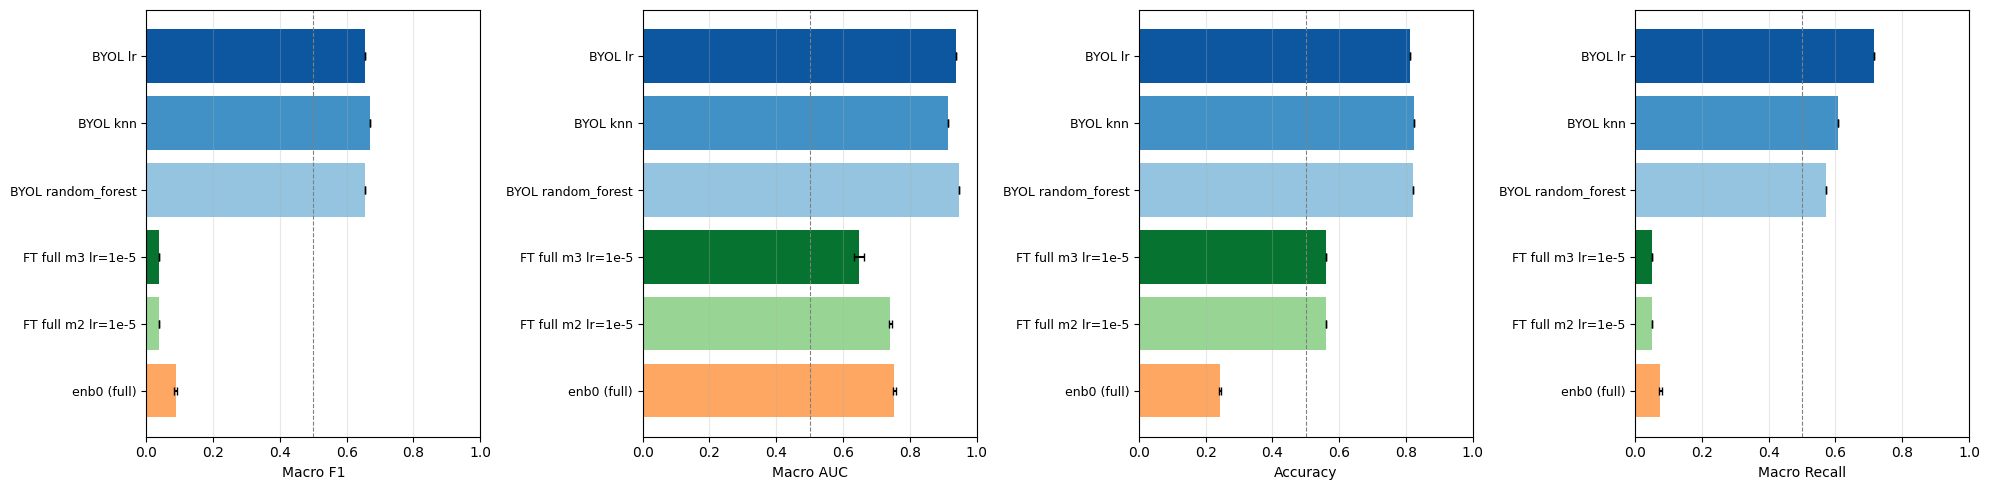

In [45]:
_KNOWN_MODELS = ("enb0", "dualssn", "vit", "cnn", "scatternet", "simplescatternet")

_baselines_dir = Path(CONFIG.get("baselines_dir", "../outputs/supervised_baseline_classifiers"))
_baselines_search_dir = (_baselines_dir / "without_generative"
                         if (_baselines_dir / "without_generative").exists()
                         else _baselines_dir)
_els = CONFIG["eval_label_set"]
_cw_bl     = CONFIG.get("class_weight", "")
_cw_tag_bl = f"cw{_cw_bl}" if _cw_bl else "cwNone"

print(f"Path : {_baselines_search_dir}")
print(f"Eval : {_els}")
print(f"CW   : {_cw_tag_bl}")

baseline_results = {}

if _baselines_dir.exists():
    # Only look in top-level dirs whose name contains the configured cw tag
    _bl_top_dirs = [
        d for d in sorted(_baselines_search_dir.iterdir())
        if d.is_dir() and (d.name.endswith(f"_{_cw_tag_bl}") or f"_{_cw_tag_bl}_" in d.name)
    ]
    print(f"Matching baseline dirs ({len(_bl_top_dirs)}): {[d.name for d in _bl_top_dirs]}")

    # Group run dirs by (model, label_set, ES-flag), one group per top-level output dir
    _model_runs = {}
    for _top_dir in _bl_top_dirs:
        for _path in sorted(_top_dir.rglob("results.json")):
            _sp = str(_path)
            if "frac_" in _sp or "gen_aug" in _sp:
                continue          # skip fraction-sweep results
            with open(_path) as _f:
                _res = json.load(_f)
            if not _res.get("class_names"):
                continue
            # Resolve run dir: parent is run-dir (run\d+) → go up one level
            _parent = _path.parent
            _resolved_top = _parent.parent if re.match(r"run\d+$", _parent.name) else _parent
            _model = next((m for m in _KNOWN_MODELS if m in _resolved_top.name.lower()), "unknown")
            _ls    = _res.get("label_set", "?")
            _es    = " ES" if "_ES_" in _resolved_top.name or _resolved_top.name.endswith("_ES") else ""
            _key   = f"{_model} ({_ls}{_es})"
            _model_runs.setdefault(_key, []).append((_parent, _res))

    for _key, _runs in _model_runs.items():
        _metrics_list = [r for _, r in _runs]
        for _m in ("f1_macro", "auc_macro", "accuracy", "recall_macro"):
            _vals = [r[_m] for r in _metrics_list if _m in r]
            baseline_results.setdefault(_key, {})[_m + "_mean"] = float(np.mean(_vals))
            baseline_results[_key][_m + "_std"] = float(np.std(_vals)) if len(_vals) > 1 else None

        # Top-5 ensemble: sort by f1_macro, average probs from top-5 runs
        _sorted_runs = sorted(_runs, key=lambda x: x[1].get("f1_macro", 0), reverse=True)
        _top_k = _sorted_runs[:min(5, len(_sorted_runs))]
        _prob_list, _y_true = [], None
        for _rd, _ in _top_k:
            _p = _rd / "test_probs.npy"
            _l = _rd / "test_labels.npy"
            if _p.exists() and _l.exists():
                _prob_list.append(np.load(_p))
                if _y_true is None:
                    _y_true = np.load(_l)
        if _prob_list and _y_true is not None:
            _ens_prob = np.mean(_prob_list, axis=0)
            _ens_pred = (_ens_prob >= 0.5).astype(int)
            from sklearn.metrics import f1_score as _f1s, roc_auc_score as _aucs
            try:
                _ens_f1  = _f1s(_y_true, _ens_pred, average="macro", zero_division=0)
                _ens_auc = _aucs(_y_true, _ens_prob, average="macro")
            except Exception:
                _ens_f1, _ens_auc = float("nan"), float("nan")
            baseline_results[_key]["top5_f1_macro"] = _ens_f1
            baseline_results[_key]["top5_auc_macro"] = _ens_auc

        _n = len(_runs)
        _f1m  = baseline_results[_key]["f1_macro_mean"]
        _f1s_v = baseline_results[_key]["f1_macro_std"] or 0.0
        print(f"  {_key}: {_n} run(s)  F1={_f1m:.3f}±{_f1s_v:.3f}")
    print(f"Loaded {len(baseline_results)} baseline group(s): {list(baseline_results.keys())}")

else:
    print(f"Baselines directory not found: {_baselines_dir}")

# ── Finetuning results ────────────────────────────────────────────────────────
def _ft_label(type_name):
    """Concise display label from a finetuning type dir name."""
    _ls_m   = re.search(r"(?:finetuning_)?(\w+?)_cw", type_name)
    _ls     = _ls_m.group(1) if _ls_m else "?"
    _es     = " ES" if "_ES_" in type_name else ""
    _mode_m = re.search(r"mode(\d+)", type_name)
    _mode   = f" m{_mode_m.group(1)}" if _mode_m else ""
    _lr_m   = re.search(r"lr([\de.-]+)", type_name)
    _lr     = f" lr={_lr_m.group(1)}" if _lr_m else ""
    return f"FT {_ls}{_es}{_mode}{_lr}"

finetuning_results = {}
_cw_ft     = CONFIG.get("class_weight", "")
_cw_tag_ft = f"cw{_cw_ft}" if _cw_ft else "cwNone"
_ft_glob   = f"{CONFIG['train_label_set']}_{_cw_tag_ft}*"
for _ft_run_path in CONFIG.get("finetuning_runs", []):
    _ft_run_dir = Path(_ft_run_path)
    for _ft_dir in sorted((_ft_run_dir / "data" / "classifiers" / "finetuning").glob(_ft_glob)):
        _ftm_path = _ft_dir / "finetuning_metrics.json"
        if not _ftm_path.exists():
            print(f"  [skip] {_ft_dir.name} — finetuning_metrics.json not found")
            continue
        with open(_ftm_path) as _f:
            _ftm = json.load(_f)

        _key = _ft_label(_ft_dir.name)

        # macro F1: stored directly as [[val], [val], ...]
        _f1_vals  = [v[0] for v in _ftm.get("macro_f1", {}).get("test", []) if v]
        # macro AUC: mean of per-class AUCs per run
        _auc_vals = [float(np.mean(v)) for v in _ftm.get("auc",  {}).get("test", []) if v]
        # macro recall: mean of per-class recalls per run
        _rec_vals = [float(np.mean(v)) for v in _ftm.get("recall", {}).get("test", []) if v]
        # accuracy: compute argmax accuracy from saved predictions per run
        _acc_vals = []
        for _rd in sorted(_ft_dir.glob("run*")):
            _pp, _lp = _rd / "test_preds.npy", _rd / "test_labels.npy"
            if _pp.exists() and _lp.exists():
                _pr, _lb = np.load(_pp), np.load(_lp)
                if _pr.ndim == 2:
                    _acc_vals.append((_pr.argmax(1) == _lb.argmax(1)).mean())
                else:
                    _acc_vals.append((_pr == _lb).mean())

        def _agg(vals):
            if not vals:
                return float("nan"), None
            return float(np.mean(vals)), (float(np.std(vals)) if len(vals) > 1 else None)

        _f1_m,  _f1_s  = _agg(_f1_vals)
        _auc_m, _auc_s = _agg(_auc_vals)
        _rec_m, _rec_s = _agg(_rec_vals)
        _acc_m, _acc_s = _agg(_acc_vals)

        finetuning_results[_key] = {
            "f1_macro_mean":    _f1_m,  "f1_macro_std":    _f1_s,
            "auc_macro_mean":   _auc_m, "auc_macro_std":   _auc_s,
            "recall_macro_mean": _rec_m, "recall_macro_std": _rec_s,
            "accuracy_mean":    _acc_m, "accuracy_std":    _acc_s,
        }
        print(f"  {_key}: {len(_f1_vals)} run(s)  F1={_f1_m:.3f}±{_f1_s or 0:.3f}")

print(f"Loaded {len(finetuning_results)} finetuning group(s): {list(finetuning_results.keys())}")

# ── Plot ──────────────────────────────────────────────────────────────────────
_metrics_to_plot = [
    ("f1_macro",     "Macro F1"),
    ("auc_macro",    "Macro AUC"),
    ("accuracy",     "Accuracy"),
    ("recall_macro", "Macro Recall"),
]

_byol_results = suite_results.get(f"lotss_{_els}", {})
_n_groups     = len(baseline_results) + len(_byol_results) + len(finetuning_results)
if _n_groups == 0:
    print("No results to plot.")
else:
    _fig, _axes = plt.subplots(1, len(_metrics_to_plot), figsize=(5 * len(_metrics_to_plot), 5))
    if len(_metrics_to_plot) == 1:
        _axes = [_axes]

    _byol_palette = plt.cm.Blues(np.linspace(0.4, 0.85, max(len(_byol_results), 1)))
    _bl_palette   = plt.cm.Oranges(np.linspace(0.4, 0.85, max(len(baseline_results), 1)))
    _ft_palette   = plt.cm.Greens(np.linspace(0.4, 0.85, max(len(finetuning_results), 1)))

    for _ax, (_mkey, _mlabel) in zip(_axes, _metrics_to_plot):
        _x, _labels, _colors, _errs = [], [], [], []
        for _i, (_bk, _bv) in enumerate(baseline_results.items()):
            _val = _bv.get(f"{_mkey}_mean", float("nan"))
            _err = _bv.get(f"{_mkey}_std") or 0.0
            _x.append(_val); _labels.append(_bk); _errs.append(_err)
            _colors.append(_bl_palette[_i])
        for _i, (_ftk, _ftv) in enumerate(finetuning_results.items()):
            _val = _ftv.get(f"{_mkey}_mean", float("nan"))
            _err = _ftv.get(f"{_mkey}_std") or 0.0
            _x.append(_val); _labels.append(_ftk); _errs.append(_err)
            _colors.append(_ft_palette[_i])
        for _i, (_ck, _cv) in enumerate(_byol_results.items()):
            _val = _cv.get("f1" if _mkey == "f1_macro" else
                           "auc" if _mkey == "auc_macro" else
                           "accuracy" if _mkey == "accuracy" else "recall", float("nan"))
            _x.append(_val); _labels.append(f"BYOL {_ck}"); _errs.append(0.0)
            _colors.append(_byol_palette[_i])

        _ys = range(len(_labels))
        _ax.barh(_ys, _x, color=_colors, xerr=_errs, capsize=3)
        _ax.set_yticks(list(_ys)); _ax.set_yticklabels(_labels, fontsize=9)
        _ax.set_xlabel(_mlabel); _ax.set_xlim(0, 1)
        _ax.axvline(0.5, color="grey", linewidth=0.8, linestyle="--")
        _ax.grid(axis="x", alpha=0.3)

    print(f"\n{_els} Classification — BYOL vs Supervised Baselines (LoTSS test split)")
    _fig.tight_layout()
    plt.show()


## 5. Fine-tuning Comparison

Per-class and macro F1 / AUC / Recall / Accuracy for fine-tuned encoder variants.
Reads `finetuning_metrics.json` from each run's fine-tuning subdirectory.

- Mode 1: frozen encoder + projector, linear head only
- Mode 2: frozen encoder, fine-tune projector + linear head
- Mode 3: fine-tune encoder + projector + linear head end-to-end

Paths:
  ../outputs/byol_runs/enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f1_sw0.05_augquart_ext_20260709_2203/
Finetuning types found: ['full_cwall0.3_mode2_lr1e-5_ep40', 'full_cwall0.3_mode2_lr1e-5_ep60', 'full_cwall0.3_mode3_lr1e-5_ep40', 'full_cwall_mode2_lr1e-5_ep40', 'full_cwall_mode2_lr1e-5_ep60', 'full_cwall_mode3_lr1e-5_ep40']
Eval : initial_pure


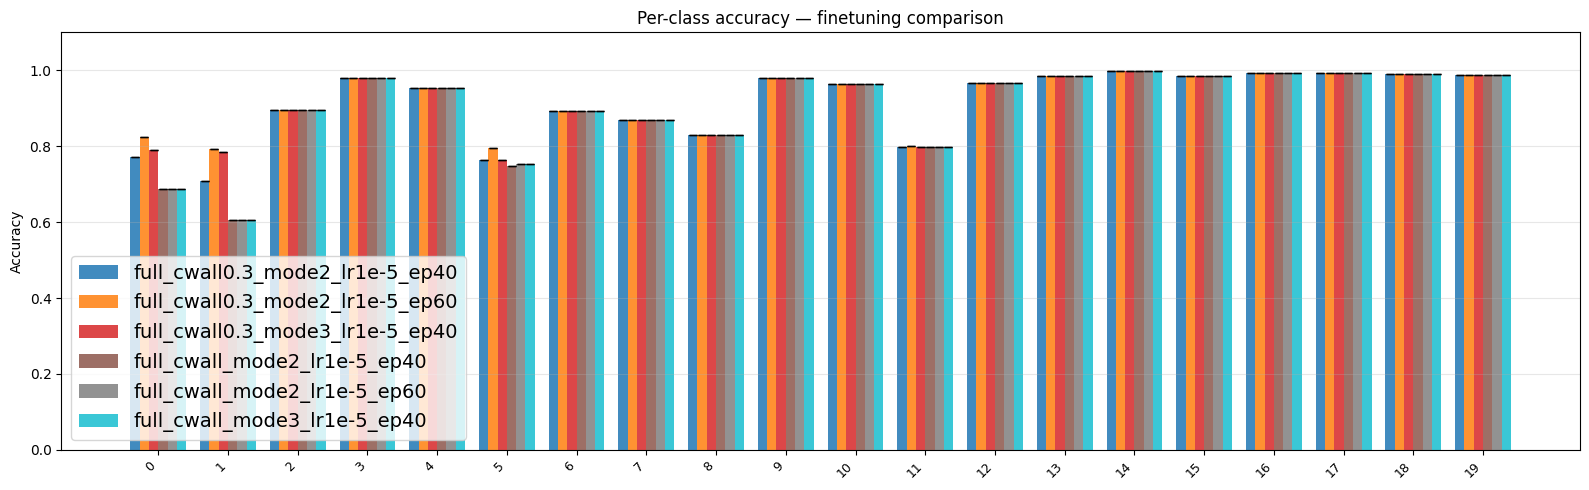

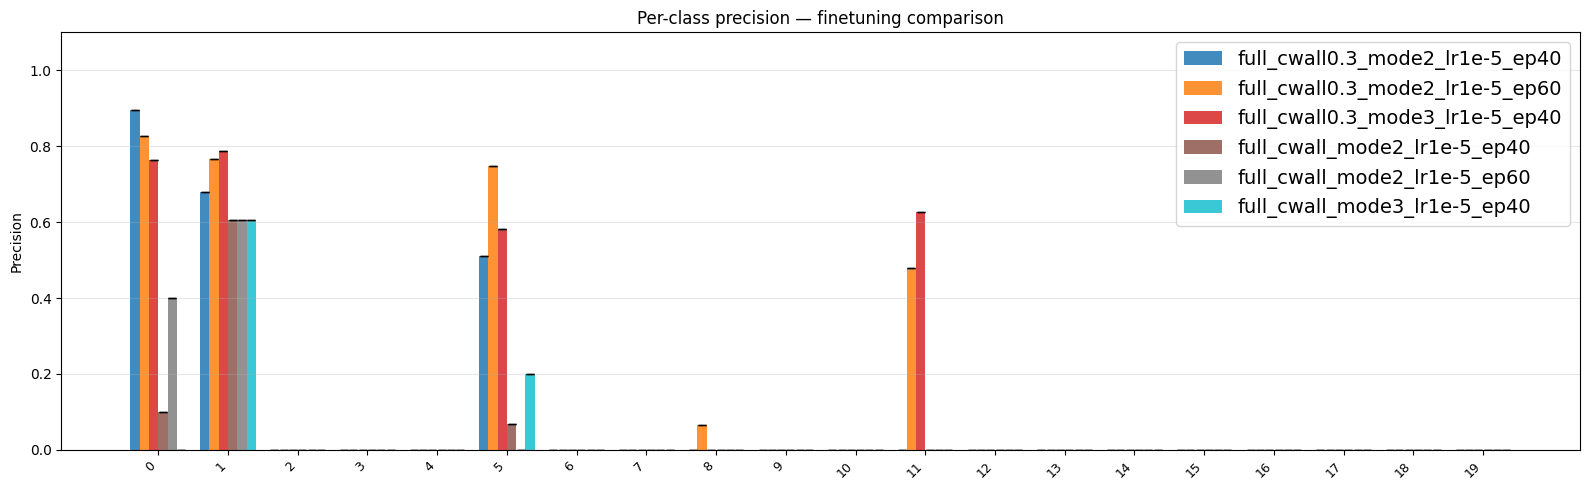

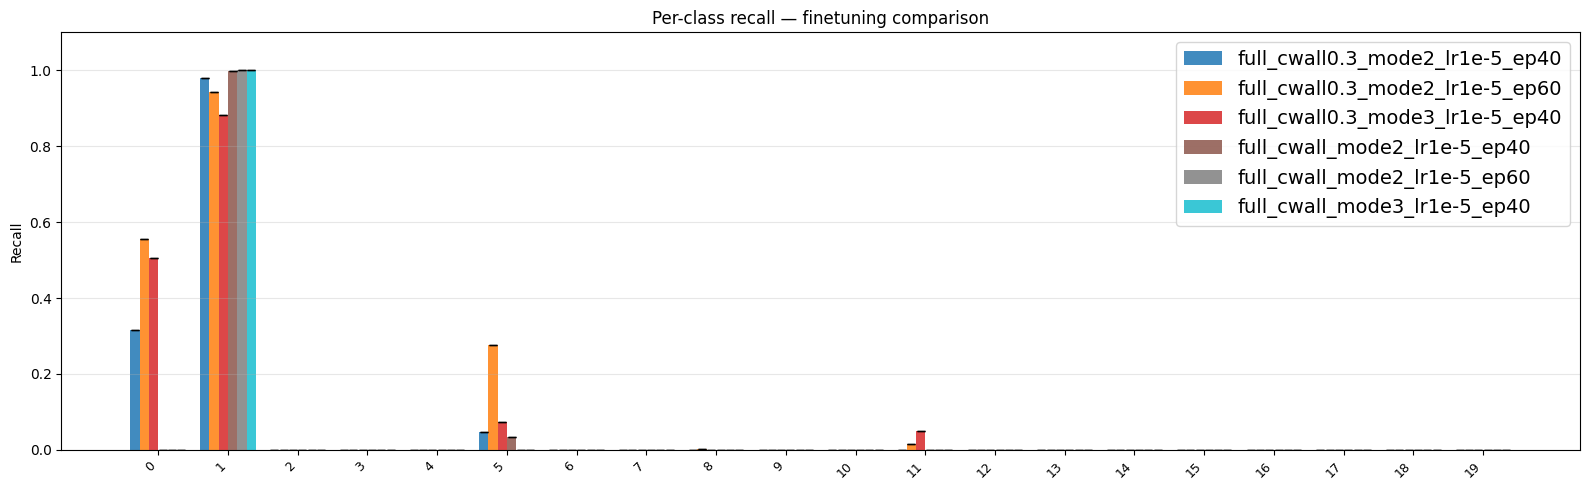

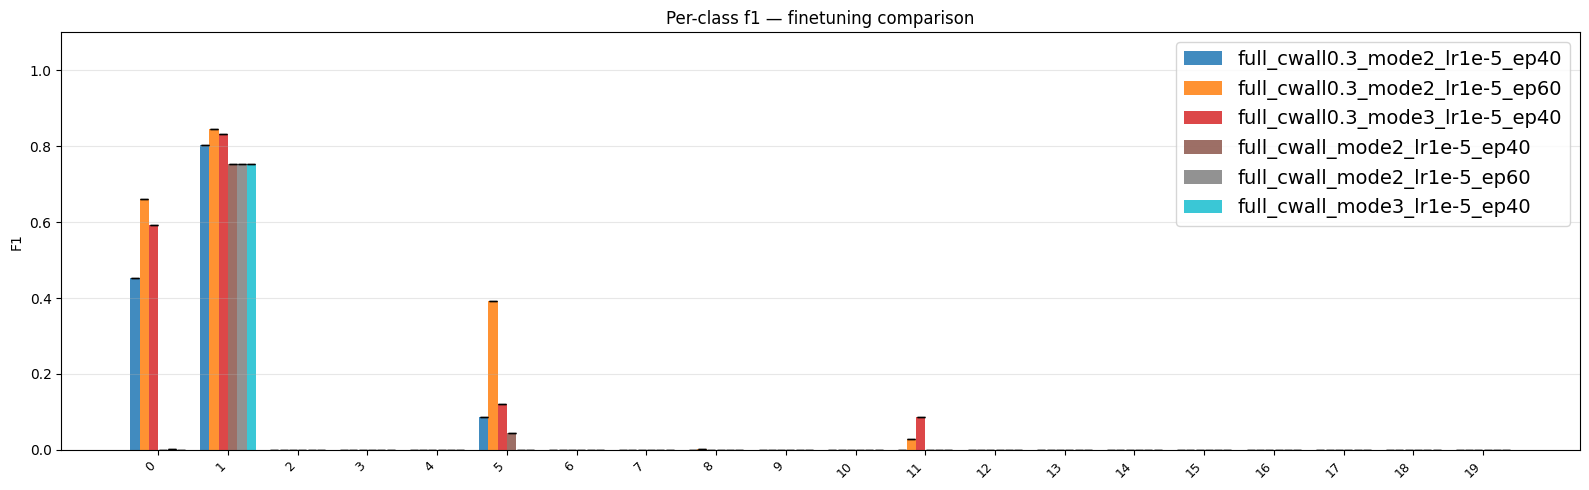

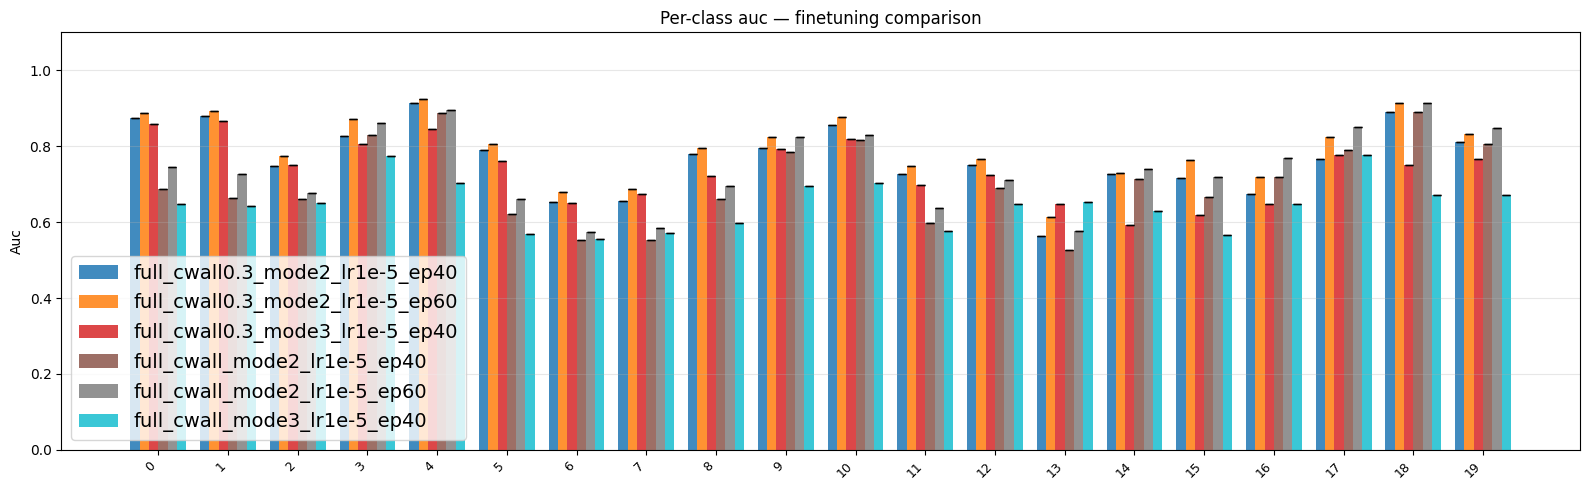

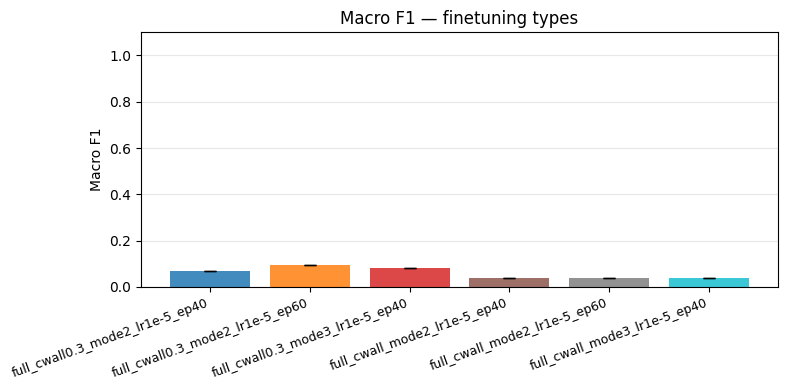

In [46]:
# ── Discover finetuning dirs from config ──────────────────────────────────────
_cw        = CONFIG.get("class_weight", "")
_cw_tag    = f"cw{_cw}" if _cw else "cwNone"
_tls       = CONFIG["train_label_set"]
_ft_prefix = f"{_tls}_{_cw_tag}"

model_paths      = CONFIG["finetuning_runs"]
finetune_types   = []
_ft_dirs_by_type = {}   # type_name -> [Path, ...]

for _rp in model_paths:
    _clf_base = Path(_rp) / "data" / "classifiers" / "finetuning"
    if not _clf_base.exists():
        continue
    for _d in sorted(_clf_base.glob(f"{_ft_prefix}*")):
        _tname = _d.name
        if _tname not in _ft_dirs_by_type:
            finetune_types.append(_tname)
            _ft_dirs_by_type[_tname] = []
        _ft_dirs_by_type[_tname].append(_d)

print("Paths:")
for _p in model_paths:
    print(f"  {_p}")
print(f"Finetuning types found: {finetune_types or '(none yet)'}")
print(f"Eval : {CONFIG['eval_label_set']}")

per_class_metrics = ["accuracy", "precision", "recall", "f1", "auc"]


def _extract_per_class_metric_ft(metrics, metric_name):
    """Mean per-class array from finetuning_metrics.json test split."""
    for _mkey in [metric_name, f"{metric_name}_macro"]:
        if _mkey not in metrics:
            continue
        _v = metrics[_mkey]
        if isinstance(_v, dict) and "test" in _v:
            _arr = np.asarray(_v["test"], dtype=np.float32)
            if _arr.ndim == 2:          # (n_runs, n_classes)
                return _arr.mean(axis=0)
            if _arr.ndim == 1:
                return _arr
    return None


def _extract_macro_f1_ft(metrics):
    """Scalar macro F1 (mean over runs) from finetuning_metrics.json."""
    for _mkey in ["macro_f1", "f1_macro"]:
        if _mkey not in metrics:
            continue
        _v = metrics[_mkey]
        if isinstance(_v, dict) and "test" in _v:
            _arr = np.asarray(_v["test"], dtype=np.float32).flatten()
            if _arr.size > 0:
                return float(_arr.mean())
    return None


metrics_by_type = {m: {} for m in per_class_metrics}
macro_f1_results = {}

for ftype in finetune_types:
    _pc_vals  = {m: [] for m in per_class_metrics}
    _mf1_vals = []
    for _d in _ft_dirs_by_type.get(ftype, []):
        _mf = _d / "finetuning_metrics.json"
        if not _mf.exists():
            continue
        with open(_mf) as _f:
            _m = json.load(_f)
        for metric in per_class_metrics:
            _arr = _extract_per_class_metric_ft(_m, metric)
            if _arr is not None:
                _pc_vals[metric].append(_arr)
        _mf1 = _extract_macro_f1_ft(_m)
        if _mf1 is not None:
            _mf1_vals.append(_mf1)
    for metric in per_class_metrics:
        if _pc_vals[metric]:
            metrics_by_type[metric][ftype] = _pc_vals[metric]
    if _mf1_vals:
        macro_f1_results[ftype] = _mf1_vals

# ── Per-class metric plots ────────────────────────────────────────────────────
_class_names_plot = ([ALL_CLASS_NAMES[i] for i in LABEL_SETS[CONFIG["eval_label_set"]]]
                     if CONFIG["eval_label_set"] in LABEL_SETS else [])

if not finetune_types:
    print("No finetuning results found — run finetuning jobs first.")
else:
    for metric_name in per_class_metrics:
        _all_data = {ft: metrics_by_type[metric_name].get(ft, []) for ft in finetune_types}
        if not any(_all_data.values()):
            print(f"Skipping {metric_name}: no data.")
            continue
        _n_cls = max((a.shape[0] for runs in _all_data.values() for a in runs), default=0)
        if _n_cls == 0:
            continue

        _fig, _ax = plt.subplots(figsize=(max(10, _n_cls * 0.8), 5))
        _x = np.arange(_n_cls)
        _w = 0.8 / max(len(finetune_types), 1)
        _colors = plt.cm.tab10(np.linspace(0, 0.9, len(finetune_types)))

        for _i, ft in enumerate(finetune_types):
            _runs = _all_data[ft]
            if not _runs:
                continue
            _stack = np.stack(_runs, axis=0)
            _mean  = _stack.mean(axis=0)
            _std   = _stack.std(axis=0) if len(_runs) > 1 else np.zeros(_n_cls)
            _ax.bar(_x + _i * _w, _mean, _w, yerr=_std, label=ft,
                    color=_colors[_i], capsize=3, alpha=0.85)

        _ax.set_xticks(_x + _w * (len(finetune_types) - 1) / 2)
        if _class_names_plot and len(_class_names_plot) == _n_cls:
            _ax.set_xticklabels(_class_names_plot, rotation=45, ha="right", fontsize=9)
        else:
            _ax.set_xticklabels([str(i) for i in range(_n_cls)], rotation=45, ha="right", fontsize=9)
        _ax.set_ylabel(metric_name.capitalize())
        _ax.set_ylim(0, 1.1)
        _ax.legend(fontsize=14)
        _ax.set_title(f"Per-class {metric_name} — finetuning comparison")
        _ax.grid(axis="y", alpha=0.3)
        _fig.tight_layout()
        plt.show()

    # ── Macro F1 summary ──────────────────────────────────────────────────────────
    if not macro_f1_results:
        print("Skipping macro_f1 plot: no data.")
    else:
        _fig, _ax = plt.subplots(figsize=(8, 4))
        _colors = plt.cm.tab10(np.linspace(0, 0.9, len(finetune_types)))
        for _i, ft in enumerate(finetune_types):
            _vals = macro_f1_results.get(ft, [])
            if not _vals:
                continue
            _mean = float(np.mean(_vals))
            _std  = float(np.std(_vals)) if len(_vals) > 1 else 0.0
            _ax.bar(_i, _mean, yerr=_std, color=_colors[_i], capsize=4, alpha=0.85, label=ft)
        _ax.set_xticks(range(len(finetune_types)))
        _ax.set_xticklabels(finetune_types, rotation=20, ha="right", fontsize=9)
        _ax.set_ylabel("Macro F1")
        _ax.set_ylim(0, 1.1)
        _ax.set_title("Macro F1 — finetuning types")
        _ax.grid(axis="y", alpha=0.3)
        _fig.tight_layout()
        plt.show()


## 6. Label Fraction

Performance as a function of labelled training fraction for three model families:

- **BYOL + LR** (dotted, hollow circles) — logistic regression on frozen projections
- **BYOL + FT** (solid, filled circles) — fine-tuned encoder (mode set in `CONFIG["finetuning_types"]`)
- **Supervised** (dashed, squares) — end-to-end supervised classifier with ±1 std band

Scans all BYOL runs under `byol_runs_dir` and supervised runs under `baselines_dir`.
Supervision weight (`sw`) is encoded as a colourbar.

In [47]:
# ── Setup (self-contained; does not depend on Section 7) ─────────────────────
_PARAM_RE = {
    "f":         r"_f([\d.]+)_",
    "sw":        r"_sw([\d.]+)_",
    "vicregvar": r"_vicregvar([\d.]+)_",
    "cov":       r"_cov([\d.]+)_",
    "gamma":     r"_gamma([\d.]+)_",
    "ema":       r"_ema([\d.]+)_",
}

def _parse_param(name, param):
    m = re.search(_PARAM_RE[param], name + "_")
    return float(m.group(1)) if m else None

_ref_name  = Path(CONFIG["checkpoint"]).parent.name
_byol_root = Path(CONFIG["byol_runs_dir"])
_run_dirs  = sorted(_byol_root.glob("enb0_*"))
_run_dirs  = [rd for rd in _run_dirs if re.search(r"_f[\d.]+_sw[\d.]+", rd.name)]
_fixed = {
    p: _parse_param(_ref_name, p)
    for p in _PARAM_RE
    if p not in ("f", "sw") and _parse_param(_ref_name, p) is not None
}
print(f"Reference run : {_ref_name}")
print(f"Fixed params  : {_fixed}")
print(f"Candidate runs: {len(_run_dirs)}")

# ── Find runs in the vicinity of the configured checkpoint ────────────────────
# "Vicinity" = same fixed hyperparams (vicregvar, cov, gamma, ema)
#              AND same aug type AND same LR schedule type.


_KNOWN_AUG     = ["augquart_ext", "augquart", "augextended", "standard"]
_KNOWN_LR_TYPE = ["lrcosine", "lrconst", "lrcyclical"]

def _parse_aug(name):
    for aug in _KNOWN_AUG:
        if f"_{aug}_" in name or name.endswith(f"_{aug}"):
            return aug
    return None

def _parse_lr_type(name):
    # strip trailing timestamp before searching
    _n = re.sub(r'_\d{8}_\d{4}$', '', name)
    for lr in _KNOWN_LR_TYPE:
        if f"_{lr}" in _n:
            return lr
    return None

_ref_aug     = _parse_aug(_ref_name)
_ref_lr_type = _parse_lr_type(_ref_name)

_target_runs = [
    rd for rd in _run_dirs
    if all(
        _parse_param(rd.name, k) is not None and abs(_parse_param(rd.name, k) - v) < 1e-9
        for k, v in _fixed.items()
    )
    and (_ref_aug     is None or _parse_aug(rd.name)     == _ref_aug)
    and (_ref_lr_type is None or _parse_lr_type(rd.name) == _ref_lr_type)
]
print(f"Found {len(_target_runs)} runs (fixed={_fixed}, aug={_ref_aug}, lr={_ref_lr_type}):")
for rd in _target_runs:
    print(f"  {rd.name}")

# ── Load pre-computed label-fraction metrics (BYOL runs) ──────────────────────
fractions   = [0.01, 0.05, 0.10, 0.25, 0.50, 1.0]
_CACHE_FILE = "label_fraction_metrics.json"
_tls    = CONFIG["train_label_set"]  # path key — files saved under train_label_set dir
_els    = CONFIG["eval_label_set"]
_cw     = CONFIG.get("class_weight", "")
_cw_tag = f"cw{_cw}" if _cw else "cwNone"
_es     = CONFIG.get("early_stopping", False)

print(f"BYOL runs : {[str(rd) for rd in _target_runs]}")
print(f"Train LS  : {_tls}")
print(f"Eval  LS  : {_els}")

# Maps run label → Path of the classifier file actually used
_clf_paths: dict = {}

def _load_metrics(run_dir):
    """Load label_fraction_metrics.json for the eval label set.

    Always reads from the tls-trained classifier directory.
    When tls != els: looks for a cross-eval fraction file; returns (None, None)
    if none exists (fraction curve unavailable for this cross-eval combination).
    Falls back to the cwNone directory if the exact CW-tagged dir doesn't exist.
    Returns (data_dict, path) or (None, None).
    """
    _sd = run_dir / "data" / "classifiers" / "simple_downstream"
    _new = _sd / f"{_tls}_{_cw_tag}"
    _fallback = _sd / f"{_tls}_cwNone"
    _clf_d = _new if _new.exists() else (_fallback if _fallback.exists() else _sd / _tls)
    if _tls != _els:
        _p = _clf_d / f"label_fraction_metrics_{_els}_eval.json"
        if not _p.exists():
            return None, None
    else:
        _p = _clf_d / _CACHE_FILE
        if not _p.exists():
            return None, None
    with open(_p) as fp:
        raw = json.load(fp)
    loaded = {float(f): v for f, v in raw.items()}
    if set(loaded.keys()) != set(fractions):
        return None, None
    return loaded, _p

def _load_single_point(run_dir):
    """Fall back to lr projections.json (or cross-eval JSON) for the 100% point.

    Always reads from the tls-trained classifier directory.
    Falls back to the cwNone directory if the exact CW-tagged dir doesn't exist.
    Returns (metrics_dict, path) or (None, None).
    """
    _sd    = run_dir / "data" / "classifiers" / "simple_downstream"
    _new   = _sd / f"{_tls}_{_cw_tag}"
    _fallback = _sd / f"{_tls}_cwNone"
    _clf_d = _new if _new.exists() else (_fallback if _fallback.exists() else _sd / _tls)
    p = (_clf_d / "lr_projections.json" if _tls == _els
         else _clf_d / f"lr_projections_{_els}_eval.json")
    if not p.exists():
        return None, None
    with open(p) as fp:
        d = json.load(fp)
    return {
        "f1":       d.get("f1_macro",     float("nan")),
        "auc":      d.get("auc_macro",    float("nan")),
        "accuracy": d.get("accuracy",     float("nan")),
        "recall":   d.get("recall_macro", float("nan")),
    }, p

all_frac_results  = {}  # {label: {f: {clf_name: {metric}}}} — full curves
single_pt_results = {}  # {label: {metric}}  — 100%-only star marker

def _unique_label(base, existing):
    """Append a counter suffix if base label already used."""
    if base not in existing:
        return base
    i = 2
    while f"{base} ({i})" in existing:
        i += 1
    return f"{base} ({i})"

for rd in _target_runs:
    f_val  = _parse_param(rd.name, "f")
    sw_val = _parse_param(rd.name, "sw")
    _base_lbl = f"f={f_val} sw={sw_val}"
    cached, cached_path = _load_metrics(rd)
    if cached is not None:
        label = _unique_label(_base_lbl, all_frac_results)
        all_frac_results[label] = cached
        _clf_paths[label] = cached_path
        print(f"→ {label}  (full fraction curve)")
        print(f"    {cached_path}")
    else:
        sp, sp_path = _load_single_point(rd)
        if sp is not None:
            label = _unique_label(_base_lbl, {**all_frac_results, **single_pt_results})
            single_pt_results[label] = sp
            _clf_paths[label] = sp_path
            print(f"★ {label}  (100% only — run train_byol_classifiers.py to get full curve)")
            print(f"    {sp_path}")
        else:
            print(f"✗ {_base_lbl}  no cache")

# ── Supervised baselines — fraction curves ────────────────────────────────────
# Each baseline run dir saves its own label_fraction_metrics.json (one per run).
# We rglob all of them, group by model label, and compute mean ± std across runs.
# Only dirs whose name contains _{_tls}_cw are considered (label-set match).
# Among those, the latest by timestamp is used.
_baselines_dir = Path(CONFIG["baselines_dir"])
_baselines_search_dir = (_baselines_dir / "without_generative"
                         if (_baselines_dir / "without_generative").exists()
                         else _baselines_dir)
baseline_frac_results = {}  # {model_label: {f: {"Supervised": {metric, metric_std}}}}
baseline_scalars      = {}  # {model_label: {metric, metric_std}} — fallback (no fraction data)

if _baselines_dir.exists():
    _bl_top_dirs = sorted(
        d for d in _baselines_search_dir.iterdir()
        if d.is_dir()
        and (d.name.endswith(f"_{_tls}_{_cw_tag}") or f"_{_tls}_{_cw_tag}_" in d.name)
        and (("_ES_" in d.name or d.name.endswith("_ES")) == _es)
    )
    _latest_bl_dir = _bl_top_dirs[-1] if _bl_top_dirs else None
    # ── Compute cross-eval fraction metrics for baselines if missing ──────────
    if _latest_bl_dir and _tls != _els and _els in {"initial_pure", "classical_pure",
                                                      "morphology_pure", "environment_pure",
                                                      "full_pure"}:
        for _bl_run_dir in sorted(_latest_bl_dir.iterdir()):
            if not _bl_run_dir.is_dir() or not _bl_run_dir.name.startswith("run"):
                continue
            _bl_xeval_cache = _bl_run_dir / f"label_fraction_metrics_{_els}_eval.json"
            if _bl_xeval_cache.exists():
                continue

            _bl_frac_xeval = {}

            # Collect per-fraction data from frac_*/run*/test_probs.npy (if present)
            for _frac_d in sorted(_bl_run_dir.glob("frac_*")):
                try:
                    _fv = float(_frac_d.name.replace("frac_", ""))
                except ValueError:
                    continue
                _run_metrics = []
                for _rr in sorted(_frac_d.glob("run*")):
                    _pb = _rr / "test_probs.npy"
                    _lb = _rr / "test_labels_20.npy"
                    if not _pb.exists() or not _lb.exists():
                        continue
                    try:
                        _m = _cross_eval_metrics(np.load(_pb), np.load(_lb), _tls, _els)
                        _run_metrics.append(_m)
                    except Exception:
                        pass
                if _run_metrics:
                    _bl_frac_xeval[str(_fv)] = {"Supervised": {
                        "f1":       float(np.mean([m["f1_macro"]     for m in _run_metrics])),
                        "auc":      float(np.mean([m["auc_macro"]    for m in _run_metrics])),
                        "accuracy": float(np.mean([m["accuracy"]     for m in _run_metrics])),
                        "recall":   float(np.mean([m["recall_macro"] for m in _run_metrics])),
                    }}

            # 100% point from run-level test_probs.npy / test_labels_20.npy
            _pb100 = _bl_run_dir / "test_probs.npy"
            _lb100 = _bl_run_dir / "test_labels_20.npy"
            if _pb100.exists() and _lb100.exists() and "1.0" not in _bl_frac_xeval:
                try:
                    _m = _cross_eval_metrics(np.load(_pb100), np.load(_lb100), _tls, _els)
                    _bl_frac_xeval["1.0"] = {"Supervised": {
                        "f1":       float(_m["f1_macro"]),
                        "auc":      float(_m["auc_macro"]),
                        "accuracy": float(_m["accuracy"]),
                        "recall":   float(_m["recall_macro"]),
                    }}
                except Exception:
                    pass

            if _bl_frac_xeval:
                with open(_bl_xeval_cache, "w") as _jf:
                    json.dump(_bl_frac_xeval, _jf, indent=2)
                print(f"  Baseline {_bl_run_dir.name}: saved {_bl_xeval_cache.name}")

    _bl_frac_by_model: dict = {}
    if _latest_bl_dir:
        print(f"Using baseline dir: {_latest_bl_dir.name}")
        _bl_cache_name = (_CACHE_FILE if _tls == _els
                          else f"label_fraction_metrics_{_els}_eval.json")
        for _rj in sorted(_latest_bl_dir.rglob(_bl_cache_name)):
            with open(_rj) as _f:
                _frd = json.load(_f)
            if not _frd:
                continue
            _first = next(iter(_frd.values()))
            if "Supervised" not in _first:
                continue
            _bl_frac_by_model.setdefault("Supervised (enb0)", []).append(_frd)
    else:
        print(f"No baseline dir found for '{_tls}', {_cw_tag}, ES={_es} in {_baselines_search_dir}")

    for _mk, _frd_list in _bl_frac_by_model.items():
        _all_fs = sorted({float(k) for _fd in _frd_list for k in _fd})
        _agg = {}
        for _fs in _all_fs:
            _vals = [_fd[str(_fs)]["Supervised"]
                     for _fd in _frd_list
                     if str(_fs) in _fd and "Supervised" in _fd.get(str(_fs), {})]
            if not _vals:
                continue
            _agg[_fs] = {"Supervised": {
                m: float(np.mean([v[m] for v in _vals]))
                for m in ("f1", "auc", "accuracy", "recall")
            }}
            for m in ("f1", "auc", "accuracy", "recall"):
                _raw = [v[m] for v in _vals]
                _agg[_fs]["Supervised"][f"{m}_std"] = (
                    float(np.std(_raw)) if len(_raw) > 1 else None
                )
        if _agg:
            baseline_frac_results[_mk] = _agg
            print(f"Baseline fraction curve: {_mk} ({len(_frd_list)} run(s), "
                  f"{len(_agg)} fractions)")

    # Scalar fallback: use the same _latest_bl_dir as fraction-curve loading.
    _bl_scalar_runs = []
    if _latest_bl_dir:
        for _rj in sorted(_latest_bl_dir.rglob("results.json")):
            if "frac_" in str(_rj):
                continue
            with open(_rj) as _f:
                _r = json.load(_f)
            if _r.get("class_names"):
                _bl_scalar_runs.append(_r)
    if _bl_scalar_runs and not baseline_frac_results:
        _f1s  = [r["f1_macro"]     for r in _bl_scalar_runs]
        _aucs = [r["auc_macro"]    for r in _bl_scalar_runs]
        _accs = [r["accuracy"]     for r in _bl_scalar_runs]
        _recs = [r["recall_macro"] for r in _bl_scalar_runs]
        baseline_scalars["Supervised (enb0)"] = {
            "f1":       float(np.mean(_f1s)),  "f1_std":       float(np.std(_f1s))  if len(_f1s)  > 1 else None,
            "auc":      float(np.mean(_aucs)), "auc_std":      float(np.std(_aucs)) if len(_aucs) > 1 else None,
            "accuracy": float(np.mean(_accs)), "accuracy_std": float(np.std(_accs)) if len(_accs) > 1 else None,
            "recall":   float(np.mean(_recs)), "recall_std":   float(np.std(_recs)) if len(_recs) > 1 else None,
        }
        print(f"Baseline scalar (fallback): {len(_bl_scalar_runs)} run(s)  "
              f"F1={np.mean(_f1s):.3f}±{np.std(_f1s):.3f}")
else:
    print(f"Baselines dir not found: {_baselines_dir}")

# ── Finetuning results — load from per-run test_probs.npy ────────────────────
# Structure produced by train_finetuning.py:
#   data/classifiers/finetuning/{name}/run{i}/test_probs.npy   ← 100% label fraction
#   data/classifiers/finetuning/{name}/frac_{f:.2f}/run{i}/test_probs.npy  ← sweep fractions
#
# For each finetuning variant we build:
#   finetuning_points      {label: {metric: mean, metric_std: std}} — 100% only
#   finetuning_frac_curves {label: {frac: {metric: mean, metric_std: std}}}
from sklearn.metrics import (f1_score as _f1_score, accuracy_score as _acc_score,
                              roc_auc_score as _auc_score, recall_score as _rec_score)
from sklearn.preprocessing import label_binarize as _label_binarize

_FT_METRICS = ("f1", "accuracy", "recall", "auc")

def _probs_to_metrics(prob_path):
    """Load test_probs/labels, return metrics dict for the configured eval_label_set."""
    _lab_path = prob_path.parent / "test_labels.npy"
    if not _lab_path.exists():
        return None
    _p = np.load(prob_path)
    _l = np.load(_lab_path)
    _eval_ls = CONFIG.get("eval_label_set", "full")
    _pure_sets = {"initial_pure", "classical_pure", "morphology_pure", "environment_pure", "full_pure"}
    if _eval_ls in _pure_sets:
        # Single-label multiclass: apply pure-set filter, argmax.
        # "full_pure": mask on all model output columns (exactly one of 20 labels set).
        # All other pure sets: mask on first 5 columns (initial class set).
        if _eval_ls == "full_pure":
            _n_cls = _p.shape[1]
            if _l.ndim == 2:
                _mask = _l[:, :_n_cls].sum(axis=1) == 1
            elif _l.ndim == 1:
                _mask = np.ones(len(_l), dtype=bool)
            else:
                return None
        else:
            _n_cls = 5
            if _l.ndim == 2 and _l.shape[1] >= 5:
                _mask = _l[:, :5].sum(axis=1) == 1
            elif _l.ndim == 1:
                _mask = np.ones(len(_l), dtype=bool)
            else:
                return None
        _p_pure = _p[_mask, :_n_cls]
        _l_pure = _l[_mask, :_n_cls] if _l.ndim == 2 else _l[_mask]
        if len(_p_pure) == 0:
            return None
        _yt = _l_pure.argmax(axis=1) if _l_pure.ndim == 2 else _l_pure
        _yp = _p_pure.argmax(axis=1)
        try:
            _auc_v = _auc_score(
                _label_binarize(_yt, classes=list(range(_p_pure.shape[1]))),
                _p_pure, multi_class="ovr", average="macro")
        except Exception:
            _auc_v = float("nan")
        return {
            "f1":       _f1_score(_yt, _yp, average="macro", zero_division=0),
            "accuracy": _acc_score(_yt, _yp),
            "recall":   _rec_score(_yt, _yp, average="macro", zero_division=0),
            "auc":      _auc_v,
        }
    else:
        # Multi-label: sigmoid threshold 0.5
        if _l.ndim != 2 or _p.ndim != 2 or _l.shape[1] != _p.shape[1]:
            return None
        _yp_bin = (_p >= 0.5).astype(int)
        try:
            _aucs = [_auc_score(_l[:, _i], _p[:, _i])
                     for _i in range(_l.shape[1]) if len(np.unique(_l[:, _i])) >= 2]
            _auc_v = float(np.mean(_aucs)) if _aucs else float("nan")
        except Exception:
            _auc_v = float("nan")
        return {
            "f1":       _f1_score(_l, _yp_bin, average="macro", zero_division=0),
            "accuracy": _acc_score(_l, _yp_bin),
            "recall":   _rec_score(_l, _yp_bin, average="macro", zero_division=0),
            "auc":      _auc_v,
        }

def _aggregate_runs(run_metrics_list):
    """Aggregate a list of per-run metric dicts into mean ± std."""
    _agg = {m: float(np.mean([r[m] for r in run_metrics_list])) for m in _FT_METRICS}
    if len(run_metrics_list) > 1:
        _agg.update({f"{m}_std": float(np.std([r[m] for r in run_metrics_list]))
                     for m in _FT_METRICS})
    return _agg

def _find_ft_dir(base, tls, cw_tag, es_tag, spec):
    """Return the first existing finetuning dir, tolerating cw_tag aliases.

    Handles two common mismatches saved by different script versions:
      cwNone   ↔ cwNone0.0
      cwall0.3 ↔ cwall        (trailing numeric suffix optional)
    """
    _candidates = [f"{tls}_{cw_tag}{es_tag}_{spec}"]
    # Strip trailing digits/decimal from cw_tag (e.g. "cwall0.3" → "cwall")
    _stripped = re.sub(r'[\d.]+$', '', cw_tag)
    if _stripped != cw_tag:
        _candidates.append(f"{tls}_{_stripped}{es_tag}_{spec}")
    # Add "0.0" suffix if cw_tag has no digits (e.g. "cwNone" → "cwNone0.0")
    if not re.search(r'[\d.]', cw_tag):
        _candidates.append(f"{tls}_{cw_tag}0.0{es_tag}_{spec}")
    for _name in _candidates:
        _d = base / _name
        if _d.exists():
            return _d
    return None

finetuning_points      = {}  # {label: {metric: mean, ...}}
finetuning_frac_curves = {}  # {label: {frac: {metric: mean, ...}}}

_cw_tag_ft = f"cw{_cw}" if _cw else "cwNone"
_es_tag    = "_ES" if _es else ""

for rd in _target_runs:
    f_val  = _parse_param(rd.name, "f")
    sw_val = _parse_param(rd.name, "sw")
    _ft_base = rd / "data" / "classifiers" / "finetuning"
    _ft_dir  = _find_ft_dir(_ft_base, _tls, _cw_tag_ft, _es_tag, CONFIG['finetuning_spec'])
    if _ft_dir is None:
        continue
    _lbl = f"f={f_val} sw={sw_val} [{_ft_dir.name}]"

    # 100% point — from run*/test_probs.npy directly in finetuning dir
    _run_ms = [m for pp in sorted(_ft_dir.glob("run*/test_probs.npy"))
               if (m := _probs_to_metrics(pp)) is not None]
    if _run_ms:
        finetuning_points[_lbl] = _aggregate_runs(_run_ms)
        print(f"Finetuning 100%: {_lbl}  F1={finetuning_points[_lbl]['f1']:.3f}"
              f"  ({len(_run_ms)} run(s))")

    # Sub-100% sweep — from frac_*/run*/test_probs.npy
    _frac_curve = {}
    for _frac_subdir in sorted(_ft_dir.glob("frac_*")):
        try:
            _fv = float(_frac_subdir.name.replace("frac_", ""))
        except ValueError:
            continue
        _fms = [m for pp in sorted(_frac_subdir.glob("run*/test_probs.npy"))
                if (m := _probs_to_metrics(pp)) is not None]
        if _fms:
            _frac_curve[_fv] = _aggregate_runs(_fms)
    if _frac_curve:
        # Merge 100% point into curve if available
        if _lbl in finetuning_points:
            _frac_curve[1.0] = finetuning_points[_lbl]
        finetuning_frac_curves[_lbl] = _frac_curve
        print(f"Finetuning curve: {_lbl}  fractions={sorted(_frac_curve.keys())}")

# ── Mode 3 (retrained encoder) results ───────────────────────────────────────
finetuning_points_m3      = {}  # mode3: full encoder retrain
finetuning_frac_curves_m3 = {}

_ft_spec_m3 = CONFIG.get("finetuning_spec_retrained")
if _ft_spec_m3:
    for rd in _target_runs:
        f_val  = _parse_param(rd.name, "f")
        sw_val = _parse_param(rd.name, "sw")
        _ft_base_m3 = rd / "data" / "classifiers" / "finetuning"
        _ft_dir_m3  = _find_ft_dir(_ft_base_m3, _tls, _cw_tag_ft, _es_tag, _ft_spec_m3)
        if _ft_dir_m3 is None:
            continue
        _lbl_m3 = f"f={f_val} sw={sw_val} [{_ft_dir_m3.name}]"

        _run_ms = [m for pp in sorted(_ft_dir_m3.glob("run*/test_probs.npy"))
                   if (m := _probs_to_metrics(pp)) is not None]
        if _run_ms:
            finetuning_points_m3[_lbl_m3] = _aggregate_runs(_run_ms)
            print(f"Retrained 100%: {_lbl_m3}  F1={finetuning_points_m3[_lbl_m3]['f1']:.3f}"
                  f"  ({len(_run_ms)} run(s))")

        _frac_curve_m3 = {}
        for _frac_subdir in sorted(_ft_dir_m3.glob("frac_*")):
            try:
                _fv = float(_frac_subdir.name.replace("frac_", ""))
            except ValueError:
                continue
            _fms = [m for pp in sorted(_frac_subdir.glob("run*/test_probs.npy"))
                    if (m := _probs_to_metrics(pp)) is not None]
            if _fms:
                _frac_curve_m3[_fv] = _aggregate_runs(_fms)
        if _frac_curve_m3:
            if _lbl_m3 in finetuning_points_m3:
                _frac_curve_m3[1.0] = finetuning_points_m3[_lbl_m3]
            finetuning_frac_curves_m3[_lbl_m3] = _frac_curve_m3
            print(f"Retrained curve: {_lbl_m3}  fractions={sorted(_frac_curve_m3.keys())}")
else:
    print("finetuning_spec_retrained not set — skipping mode3 loading.")

print(f"\nLoaded {len(all_frac_results)} BYOL curve(s),  "
      f"{len(single_pt_results)} single-point(s),  "
      f"{len(baseline_frac_results)} baseline curve(s),  "
      f"{len(baseline_scalars)} baseline scalar(s),  "
      f"{len(finetuning_points)} finetuning 100%-point(s),  "
      f"{len(finetuning_frac_curves)} finetuning curve(s),  "
      f"{len(finetuning_points_m3)} retrained 100%-point(s),  "
      f"{len(finetuning_frac_curves_m3)} retrained curve(s).")

Reference run : enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f1_sw0.05_augquart_ext_20260709_2203
Fixed params  : {'vicregvar': 2.0, 'cov': 0.1, 'gamma': 0.25, 'ema': 0.996}
Candidate runs: 111
Found 11 runs (fixed={'vicregvar': 2.0, 'cov': 0.1, 'gamma': 0.25, 'ema': 0.996}, aug=augquart_ext, lr=lrconst):
  enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f0.1_sw0.05_augquart_ext_20260720_1528
  enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f0.1_sw3_augquart_ext_20260714_1550
  enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f0.5_sw0.05_augquart_ext_20260720_1619
  enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f0.5_sw3_augquart_ext_20260714_1636
  enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f0_sw0.0_augquart_ext_20260720_1709
  enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamm

=== Model paths ===
Reference checkpoint : ../outputs/byol_runs/enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f1_sw0.05_augquart_ext_20260709_2203/byol_model_best.pt
Reference run        : enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f1_sw0.05_augquart_ext_20260709_2203
Train label set      : full
Eval  label set      : initial_pure

BYOL target runs (11):
  [no data] enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f0.1_sw0.05_augquart_ext_20260720_1528
    classifier: —
  [full curve] enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f0.1_sw3_augquart_ext_20260714_1550
    classifier: ../outputs/byol_runs/enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f0.1_sw3_augquart_ext_20260714_1550/data/classifiers/simple_downstream/full_cwall/label_fraction_metrics_initial_pure_eval.json
  [no data] enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0

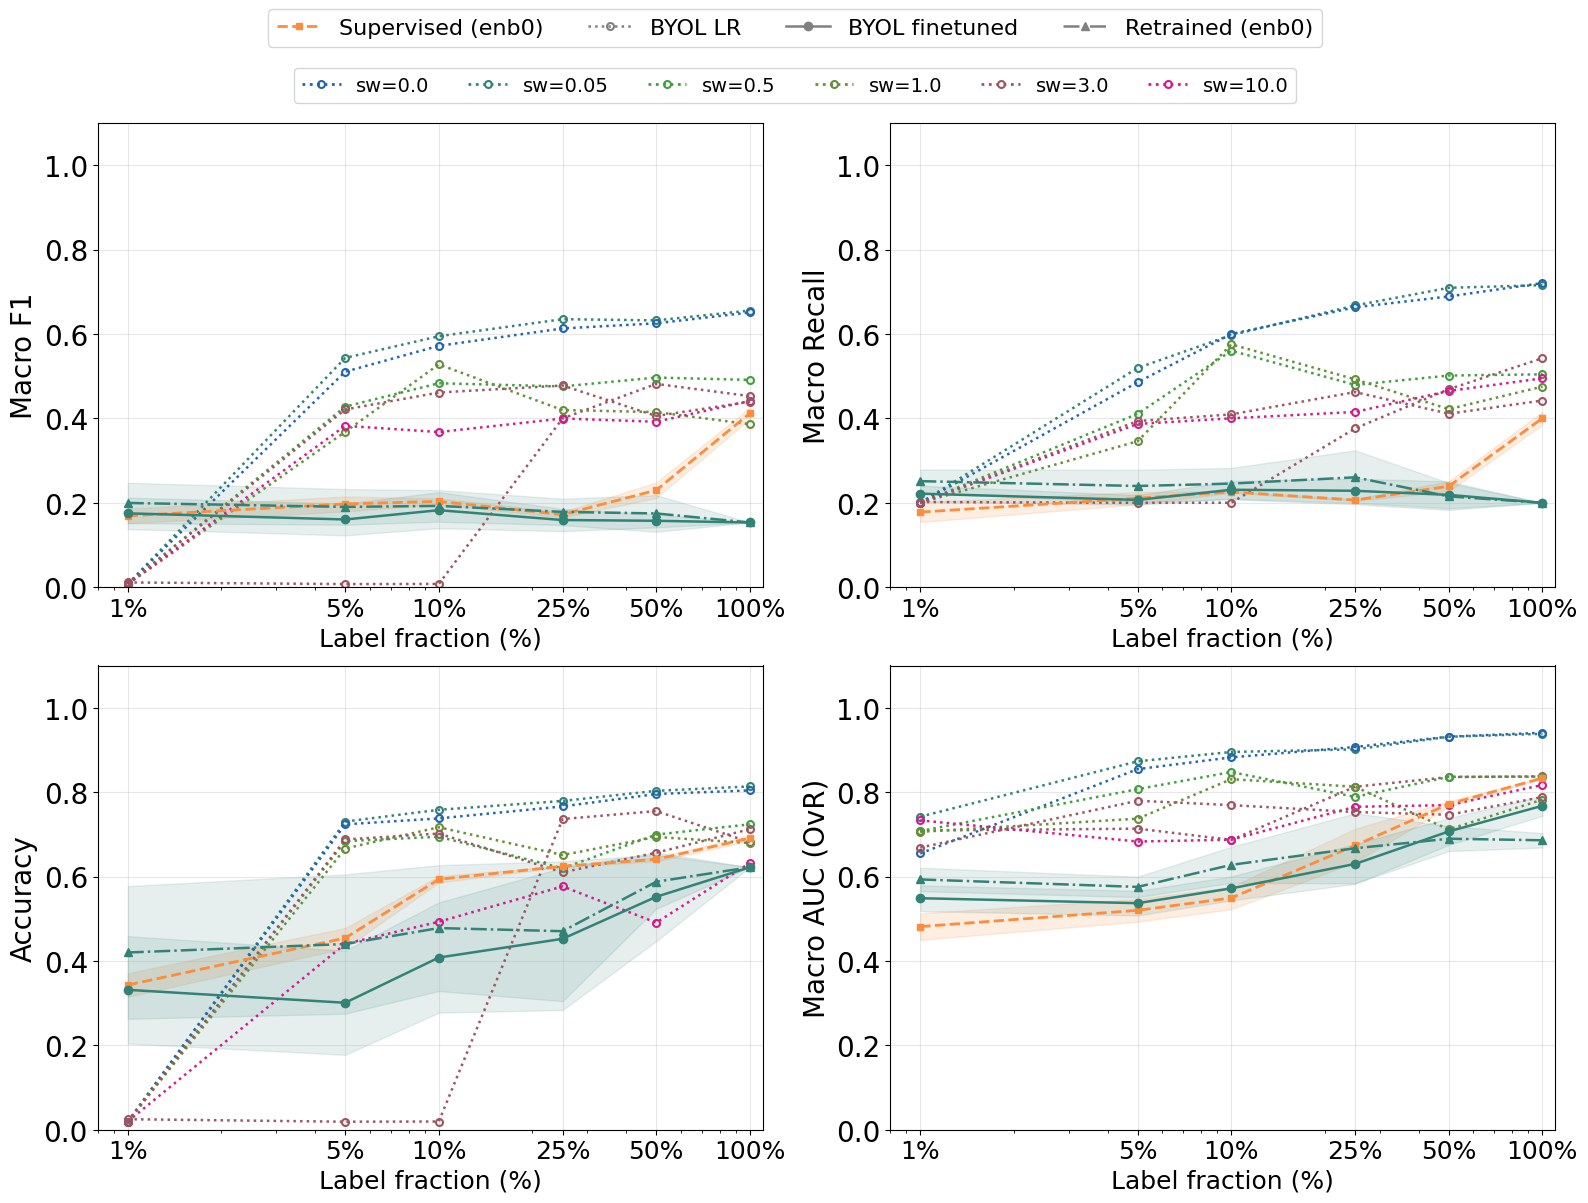

Saved → ../outputs/figures/classification/label_fraction_enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f1_sw0.05_augquart_ext_20260709_2203.png


In [48]:
# ── Print all model paths used in this plot ───────────────────────────────────
print("=== Model paths ===")
print(f"Reference checkpoint : {CONFIG['checkpoint']}")
print(f"Reference run        : {_ref_name}")
print(f"Train label set      : {_tls}")
print(f"Eval  label set      : {_els}")
print(f"\nBYOL target runs ({len(_target_runs)}):")
for _rd in _target_runs:
    _lbl = f"f={_parse_param(_rd.name, 'f')} sw={_parse_param(_rd.name, 'sw')}"
    _matched_lbl = next((k for k in {**all_frac_results, **single_pt_results} if _lbl in k), None)
    _in_frac = _lbl in all_frac_results or any(_lbl in k for k in all_frac_results)
    _in_sp   = _lbl in single_pt_results or any(_lbl in k for k in single_pt_results)
    _status  = "full curve" if _in_frac else ("100% only" if _in_sp else "no data")
    _used_path = _clf_paths.get(_matched_lbl, "—")
    print(f"  [{_status}] {_rd.name}")
    print(f"    classifier: {_used_path}")
print(f"\nBaseline fraction curves ({len(baseline_frac_results)}): {list(baseline_frac_results.keys())}")
print(f"Baseline scalars      ({len(baseline_scalars)}): {list(baseline_scalars.keys())}")
_ft_all = {**finetuning_points, **finetuning_frac_curves,
           **finetuning_points_m3, **finetuning_frac_curves_m3}
print(f"\nFinetuning results ({len(_ft_all)}):")
for _k in sorted(_ft_all):
    print(f"  {_k}")
print()

_metrics    = [("f1", "Macro F1"), ("recall", "Macro Recall"),
               ("accuracy", "Accuracy"), ("auc", "Macro AUC (OvR)")]

# ── Finetuning dicts — mode2 (BYOL finetuned) and mode3 (Retrained) ───────────
_ft_points_plot    = dict(finetuning_points)
_ft_curves_plot    = dict(finetuning_frac_curves)
_ft_points_plot_m3 = dict(finetuning_points_m3)
_ft_curves_plot_m3 = dict(finetuning_frac_curves_m3)

# ── Discrete colour mapping: one colour per unique sw value ───────────────────
def _sw_from_label(lbl):
    m = re.search(r'sw=([\d.]+)', lbl)
    return float(m.group(1)) if m else None

_sw_cmap_cont = mcolors.LinearSegmentedColormap.from_list(
    "sw_cmap", ["#2166ac", "#4dac26", "#d01c8b"]  # blue → green → magenta
)
_all_run_labels = (list(all_frac_results.keys())
                   + [l for l in single_pt_results if l not in all_frac_results]
                   + list(_ft_points_plot.keys())
                   + [l for l in _ft_curves_plot if l not in _ft_points_plot]
                   + list(_ft_points_plot_m3.keys())
                   + [l for l in _ft_curves_plot_m3 if l not in _ft_points_plot_m3])
_all_sw = [_sw_from_label(l) for l in _all_run_labels]
_sw_vals = [v for v in _all_sw if v is not None]
_sw_vals_unique = sorted(set(_sw_vals)) if _sw_vals else [0.0]
_n_sw = len(_sw_vals_unique)

# Sample one colour per unique sw value, spread evenly over the full cmap range
_sw_color_list = [_sw_cmap_cont(i / max(_n_sw - 1, 1)) for i in range(_n_sw)]
_sw_color_map  = dict(zip(_sw_vals_unique, _sw_color_list))
_run_colors    = {lbl: (_sw_color_map.get(sw, "grey") if sw is not None else "grey")
                  for lbl, sw in zip(_all_run_labels, _all_sw)}


_bl_labels  = list(baseline_frac_results.keys()) + list(baseline_scalars.keys())
_bl_all     = sorted(set(_bl_labels))
_bl_palette = plt.cm.Oranges(np.linspace(0.5, 0.85, max(len(_bl_all), 1)))
_bl_colors  = {lbl: _bl_palette[i] for i, lbl in enumerate(_bl_all)}

xs_pct = [f * 100 for f in fractions]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

# ── Classifier priority for BYOL curves (use first available key) ─────────────
_BYOL_CLF_PRIORITY = ["LogReg", "LR", "RF", "KNN"]

def _pick_clf_val(frac_data, metric):
    for _clf in _BYOL_CLF_PRIORITY:
        if _clf in frac_data:
            return frac_data[_clf].get(metric, float("nan"))
    return float("nan")

for ax, (metric, ylabel) in zip(axes, _metrics):
    # BYOL full label-fraction curves — dotted lines with hollow circles
    for run_lbl, res in all_frac_results.items():
        ys = [_pick_clf_val(res[f], metric) for f in fractions]
        ax.plot(xs_pct, ys, linestyle=":", color=_run_colors[run_lbl],
                linewidth=1.8, marker="o", markersize=5,
                markerfacecolor="none", markeredgewidth=1.5)

    # BYOL 100%-only fallback — hollow circle at x=100
    for sp_lbl, sp in single_pt_results.items():
        v = sp.get(metric, float("nan"))
        if v == v:
            ax.plot(100, v, marker="o", markersize=7, linestyle="none",
                    color=_run_colors[sp_lbl],
                    markerfacecolor="none", markeredgewidth=1.5, zorder=5)

    # Supervised baseline fraction curves with shaded std bands
    for bl_lbl, bl_res in baseline_frac_results.items():
        bl_fs  = sorted(bl_res.keys())
        bl_xs  = [f * 100 for f in bl_fs]
        ys     = [bl_res[f]["Supervised"].get(metric, float("nan")) for f in bl_fs]
        ys_std = [bl_res[f]["Supervised"].get(f"{metric}_std") for f in bl_fs]
        col    = _bl_colors[bl_lbl]
        ax.plot(bl_xs, ys, linestyle="--", color=col, linewidth=2.0, marker="s", markersize=5)
        _lo = [y - (s if s is not None else 0) for y, s in zip(ys, ys_std)]
        _hi = [y + (s if s is not None else 0) for y, s in zip(ys, ys_std)]
        if any(s is not None for s in ys_std):
            ax.fill_between(bl_xs, _lo, _hi, color=col, alpha=0.15)

    # Supervised baseline scalar fallback — single square at 100%
    for bl_lbl, bl in baseline_scalars.items():
        v = bl.get(metric, float("nan"))
        if v == v:
            col = _bl_colors[bl_lbl]
            ax.plot(100, v, marker="s", markersize=8, color=col,
                    linestyle="none", zorder=5)
            std = bl.get(f"{metric}_std")
            if std:
                ax.errorbar(100, v, yerr=std, fmt="none", color=col,
                            capsize=4, linewidth=1.5)

    # BYOL finetuned (mode2) full curves — solid line with filled circles
    for ft_lbl, ft_curve in _ft_curves_plot.items():
        ft_fs = sorted(ft_curve.keys())
        ft_xs = [f * 100 for f in ft_fs]
        ys    = [ft_curve[f].get(metric, float("nan")) for f in ft_fs]
        stds  = [ft_curve[f].get(f"{metric}_std") for f in ft_fs]
        col   = _run_colors.get(ft_lbl, "grey")
        ax.plot(ft_xs, ys, linestyle="-", color=col, linewidth=1.8,
                marker="o", markersize=6, zorder=6)
        _lo = [y - (s if s is not None else 0) for y, s in zip(ys, stds)]
        _hi = [y + (s if s is not None else 0) for y, s in zip(ys, stds)]
        if any(s is not None for s in stds):
            ax.fill_between(ft_xs, _lo, _hi, color=col, alpha=0.12)

    # BYOL finetuned (mode2) 100%-only fallback — single filled circle at x=100
    for ft_lbl, ft in _ft_points_plot.items():
        if ft_lbl in _ft_curves_plot:
            continue  # already plotted as a full curve above
        v = ft.get(metric, float("nan"))
        if v != v:
            continue
        col = _run_colors.get(ft_lbl, "grey")
        ax.plot(100, v, linestyle="none", marker="o", markersize=7,
                color=col, zorder=6)
        std = ft.get(f"{metric}_std")
        if std:
            ax.errorbar(100, v, yerr=std, fmt="none", color=col,
                        capsize=4, linewidth=1.5, zorder=6)

    # Retrained (mode3) full curves — dash-dot line with triangle markers
    for ft_lbl, ft_curve in _ft_curves_plot_m3.items():
        ft_fs = sorted(ft_curve.keys())
        ft_xs = [f * 100 for f in ft_fs]
        ys    = [ft_curve[f].get(metric, float("nan")) for f in ft_fs]
        stds  = [ft_curve[f].get(f"{metric}_std") for f in ft_fs]
        col   = _run_colors.get(ft_lbl, "grey")
        ax.plot(ft_xs, ys, linestyle="-.", color=col, linewidth=1.8,
                marker="^", markersize=6, zorder=6)
        _lo = [y - (s if s is not None else 0) for y, s in zip(ys, stds)]
        _hi = [y + (s if s is not None else 0) for y, s in zip(ys, stds)]
        if any(s is not None for s in stds):
            ax.fill_between(ft_xs, _lo, _hi, color=col, alpha=0.12)

    # Retrained (mode3) 100%-only fallback — single filled triangle at x=100
    for ft_lbl, ft in _ft_points_plot_m3.items():
        if ft_lbl in _ft_curves_plot_m3:
            continue
        v = ft.get(metric, float("nan"))
        if v != v:
            continue
        col = _run_colors.get(ft_lbl, "grey")
        ax.plot(100, v, linestyle="none", marker="^", markersize=7,
                color=col, zorder=6)
        std = ft.get(f"{metric}_std")
        if std:
            ax.errorbar(100, v, yerr=std, fmt="none", color=col,
                        capsize=4, linewidth=1.5, zorder=6)

    ax.set_xscale("log")
    ax.set_xlim(xs_pct[0] * 0.8, xs_pct[-1] * 1.1)  # ensure positive view limits on log scale
    ax.set_xlabel("Label fraction (%)", fontsize=18)
    ax.set_ylabel(ylabel, fontsize=20)
    ax.set_xticks(xs_pct)
    ax.set_xticklabels([f"{x:.0f}%" for x in xs_pct], fontsize=18)
    ax.tick_params(axis="y", labelsize=20)
    ax.set_ylim(0, 1.1)
    ax.grid(True, alpha=0.3)

plt.tight_layout()

# ── Legend — top-left ──────────────────────────────────────────────────────────
_legend_handles = []
for lbl in baseline_frac_results:
    _legend_handles.append(
        plt.Line2D([0], [0], color=_bl_colors[lbl], linestyle="--",
                   linewidth=2.0, marker="s", markersize=5, label=lbl))
for lbl in baseline_scalars:
    _legend_handles.append(
        plt.Line2D([0], [0], color=_bl_colors[lbl], linestyle="none",
                   marker="s", markersize=8, label=f"{lbl} (100% only)"))
_legend_handles.append(
    plt.Line2D([0], [0], color="grey", linestyle=":", linewidth=1.8,
               marker="o", markersize=5, markerfacecolor="none", markeredgewidth=1.5,
               label="BYOL LR"))
if _ft_curves_plot or _ft_points_plot:
    _legend_handles.append(
        plt.Line2D([0], [0], color="grey", linestyle="-", linewidth=1.8,
                   marker="o", markersize=6, label="BYOL finetuned"))
if _ft_curves_plot_m3 or _ft_points_plot_m3:
    _legend_handles.append(
        plt.Line2D([0], [0], color="grey", linestyle="-.", linewidth=1.8,
                   marker="^", markersize=6, label="Retrained (enb0)"))
# ── Row 1 (top): curve-type legend ───────────────────────────────────────────
if _legend_handles:
    fig.legend(handles=_legend_handles, loc="upper center",
               ncol=len(_legend_handles), fontsize=16,
               bbox_to_anchor=(0.5, 1.10), frameon=True)

# ── Row 2 (below): supervision weight legend ──────────────────────────────────
_sw_legend_handles = [
    plt.Line2D([0], [0], color=_sw_color_list[i], linestyle=":", linewidth=2,
               marker="o", markersize=5, markerfacecolor="none", markeredgewidth=1.5,
               label=f"sw={v}")
    for i, v in enumerate(_sw_vals_unique)
]
if _sw_legend_handles:
    fig.legend(handles=_sw_legend_handles, loc="upper center",
               ncol=len(_sw_legend_handles), fontsize=14,
               bbox_to_anchor=(0.5, 1.045), frameon=True,
               title=None)

_out = f"{OUT_DIR}/label_fraction_{_ref_name}.png"
plt.savefig(_out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {_out}")

## 7. Hyperparameter Sweep

Reads pre-computed classifier results from `data/classifiers/` across all BYOL run
directories and produces sweep line plots. The reference run (from `CONFIG["checkpoint"]`) pins
all hyperparameters except the two sweep axes (`axis_x` / `axis_y`).

Configure sweep axes, classifier, and run search pattern in `GRID_CONFIG` (Section 0).
Each plot shows metric vs. one sweep variable, with lines coloured by the other variable
and linestyle indicating the downstream classifier (RF / KNN / LR).

Fixed params: {'vicregvar': 2.0, 'cov': 0.1, 'gamma': 0.25, 'ema': 0.996}
Reference augmentation: augquart_ext  LR schedule: lrconst
  rf: 7 run(s) found


  knn: 7 run(s) found
  lr: 7 run(s) found
Sweep: f  |  initial_pure (train=full), projections, cwall  |  fixed: {'vicregvar': 2.0, 'cov': 0.1, 'gamma': 0.25, 'ema': 0.996}
Sweep: sw  |  initial_pure (train=full), projections, cwall  |  fixed: {'vicregvar': 2.0, 'cov': 0.1, 'gamma': 0.25, 'ema': 0.996}


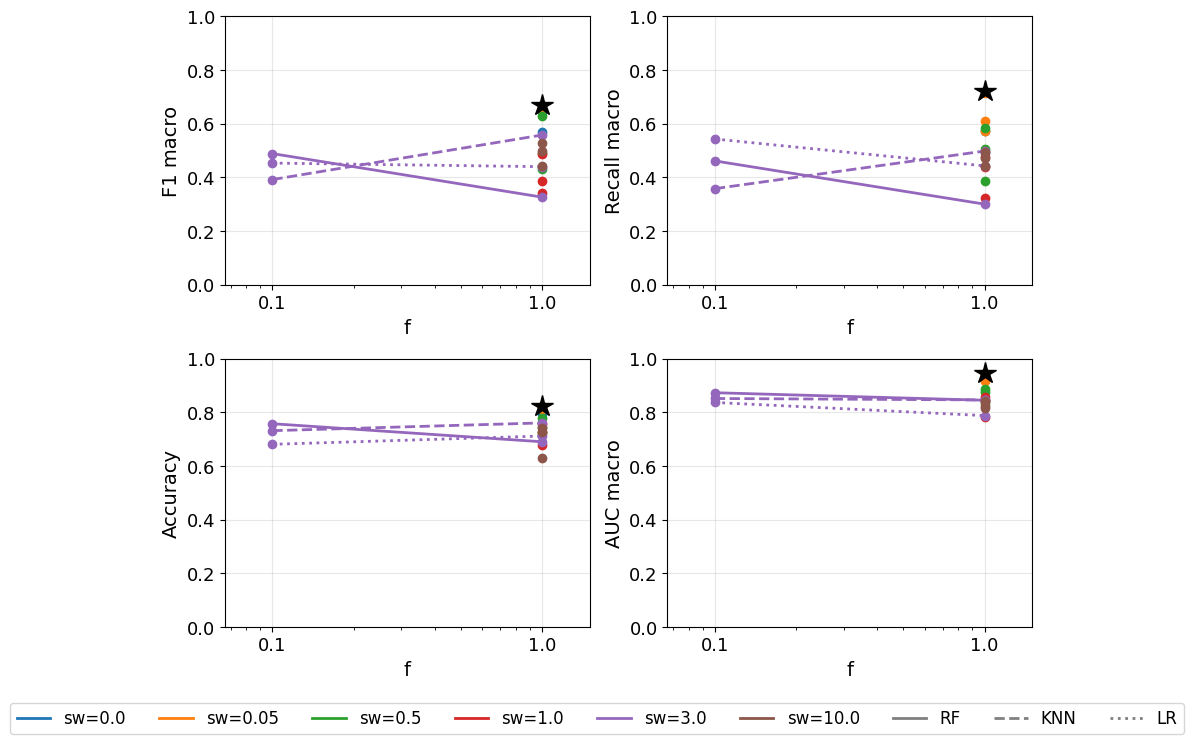

Saved → ../outputs/figures/classification/sweep_lines_enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f1_sw0.05_augquart_ext_20260709_2203_f_initial_pure.png


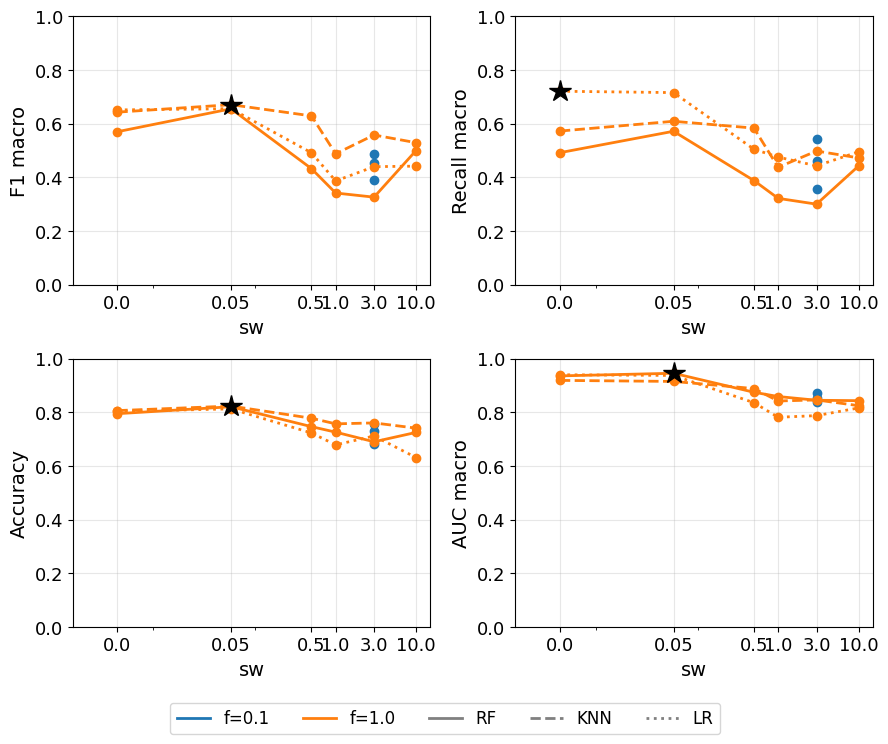

Saved → ../outputs/figures/classification/sweep_lines_enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f1_sw0.05_augquart_ext_20260709_2203_sw_initial_pure.png


In [49]:
# ── Parseable hyperparameter patterns ─────────────────────────────────────────
_PARAM_RE = {
    "f":         r"_f([\d.]+)_",
    "sw":        r"_sw([\d.]+)_",
    "vicregvar": r"_vicregvar([\d.]+)_",
    "cov":       r"_cov([\d.]+)_",
    "gamma":     r"_gamma([\d.]+)_",
    "ema":       r"_ema([\d.]+)_",
}

def _parse_param(name, param):
    m = re.search(_PARAM_RE[param], name + "_")
    return float(m.group(1)) if m else None

# ── Infer fixed params from the reference run ──────────────────────────────────
_ref_name  = Path(CONFIG["checkpoint"]).parent.name
_axis_x    = GRID_CONFIG["axis_x"]
_axis_y    = GRID_CONFIG["axis_y"]
_fixed = {
    p: _parse_param(_ref_name, p)
    for p in _PARAM_RE
    if p not in (_axis_x, _axis_y) and _parse_param(_ref_name, p) is not None
}
print("Fixed params:", _fixed)

# ── Scan run directories ────────────────────────────────────────────────────────
_root     = Path(GRID_CONFIG["outputs_root"])
_run_dirs = sorted(_root.glob(GRID_CONFIG["run_glob"]))
_run_dirs = [rd for rd in _run_dirs if re.search(r"_f[\d.]+_sw[\d.]+", rd.name)]

# ── Fix augmentation and LR schedule to match the reference run ───────────────
_KNOWN_AUG     = ["augquart_ext", "augquart", "augextended", "augbaronperez", "standard"]
_KNOWN_LR_TYPE = ["lrcosine", "lrconst", "lrcyclical"]

def _parse_aug(name):
    for aug in _KNOWN_AUG:
        if f"_{aug}_" in name or name.endswith(f"_{aug}"):
            return aug
    return None

def _parse_lr_type(name):
    _n = re.sub(r'_\d{8}_\d{4}$', '', name)
    for lr in _KNOWN_LR_TYPE:
        if f"_{lr}" in _n:
            return lr
    return None

_ref_aug     = _parse_aug(_ref_name)
_ref_lr_type = _parse_lr_type(_ref_name)
print(f"Reference augmentation: {_ref_aug}  LR schedule: {_ref_lr_type}")

_run_dirs = [
    rd for rd in _run_dirs
    if (_ref_aug     is None or _parse_aug(rd.name)     == _ref_aug)
    and (_ref_lr_type is None or _parse_lr_type(rd.name) == _ref_lr_type)
]

_CLFS  = ["rf", "knn", "lr"]
_CLF_STYLES = {"rf": "-", "knn": "--", "lr": ":"}
_CLF_LABELS = {"rf": "RF", "knn": "KNN", "lr": "LR"}
_tls   = CONFIG["train_label_set"]
_els   = CONFIG["eval_label_set"]
_feat  = GRID_CONFIG["feature_type"]
_gcw   = CONFIG.get("class_weight", "")
_gcw_tag = f"cw{_gcw}" if _gcw else "cwNone"

# Build records per classifier
_records = {}
for _clf in _CLFS:
    _records[_clf] = []
    for rd in _run_dirs:
        params = {p: _parse_param(rd.name, p) for p in _PARAM_RE}
        if not all(
            params.get(k) is not None and abs(params[k] - v) < 1e-9
            for k, v in _fixed.items()
        ):
            continue
        _sd = rd / "data" / "classifiers" / "simple_downstream"
        _clf_dir = _sd / f"{_tls}_{_gcw_tag}"
        if not _clf_dir.exists():
            _clf_dir = _sd / _tls   # fallback to old layout
        if _tls == _els:
            json_path = _clf_dir / f"{_clf}_{_feat}.json"
        else:
            json_path = _clf_dir / f"{_clf}_{_feat}_{_els}_eval.json"
        if not json_path.exists():
            continue
        with open(json_path) as _fh:
            _d = json.load(_fh)
        _records[_clf].append({
            "x":   params[_axis_x],
            "y":   params[_axis_y],
            "f1":  _d.get("f1_macro",     float("nan")),
            "auc": _d.get("auc_macro",    float("nan")),
            "acc": _d.get("accuracy",     float("nan")),
            "rec": _d.get("recall_macro", float("nan")),
        })
    print(f"  {_clf}: {len(_records[_clf])} run(s) found")

_grids = {_clf: {(r["x"], r["y"]): r for r in recs}
          for _clf, recs in _records.items()}
_all_recs = [r for recs in _records.values() for r in recs]
_xs = sorted(set(r["x"] for r in _all_recs))
_ys = sorted(set(r["y"] for r in _all_recs))

_METRICS   = [("f1", "F1 macro"), ("rec", "Recall macro"),
              ("acc", "Accuracy"), ("auc", "AUC macro")]
_line_cmap = plt.cm.tab10

# Print sweep summary once (outside the widget function so it stays above the plot)
for sweep_var, sweep_vals in [(_axis_x, _xs), (_axis_y, _ys)]:
    if len(sweep_vals) < 2:
        print(f"Skipping {sweep_var} sweep (only {len(sweep_vals)} value(s))")
    else:
        print(f"Sweep: {sweep_var}  |  {_els} (train={_tls}), {_feat}, {_gcw_tag}  |  fixed: {_fixed}")

# ── Plot ───────────────────────────────────────────────────────────────────────
for sweep_var, group_var, sweep_vals, group_vals, axis_is_x in [
    (_axis_x, _axis_y, _xs, _ys, True),
    (_axis_y, _axis_x, _ys, _xs, False),
]:
    if len(sweep_vals) < 2:
        continue

    fig, axes = plt.subplots(2, 2, figsize=(9, 7), sharey=False)

    for ax, (mkey, mlabel) in zip(axes.flat, _METRICS):
        # Collect all plotted (x, y) values to find the global max
        _all_plot_pts = []

        for gi, gv in enumerate(group_vals):
            color = _line_cmap(gi % 10)
            for _clf in _CLFS:
                xs_plot, ys_plot = [], []
                for sv in sweep_vals:
                    key = (sv, gv) if axis_is_x else (gv, sv)
                    rec = _grids[_clf].get(key)
                    val = rec[mkey] if rec is not None else float("nan")
                    if val == val:
                        xs_plot.append(sv)
                        ys_plot.append(val)
                if not xs_plot:
                    continue
                ax.plot(xs_plot, ys_plot,
                        marker="o", markersize=6, linewidth=2.0,
                        linestyle=_CLF_STYLES[_clf],
                        color=color,
                        label=f"{group_var}={gv} / {_CLF_LABELS[_clf]}")
                _all_plot_pts.extend(zip(xs_plot, ys_plot))

        # Mark the highest point with a star
        if _all_plot_pts:
            _best_x, _best_y = max(_all_plot_pts, key=lambda p: p[1])
            ax.plot(_best_x, _best_y, marker="*", markersize=16,
                    color="black", zorder=10, linestyle="none")

        ax.set_xlabel(sweep_var, fontsize=14)
        ax.set_ylabel(mlabel, fontsize=14)
        _sv_min, _sv_max = min(sweep_vals), max(sweep_vals)
        _has_zero = _sv_min == 0
        if _has_zero:
            _nonzero = [v for v in sweep_vals if v != 0]
            _linthresh = min(_nonzero) / 2 if _nonzero else 0.01
            ax.set_xscale("symlog", linthresh=_linthresh)
            ax.set_xlim(-_linthresh * 0.5, _sv_max * 1.5)
        else:
            ax.set_xscale("log")
            ax.set_xlim(_sv_min / 1.5, _sv_max * 1.5)
        ax.set_xticks(sweep_vals)
        ax.set_xticklabels([str(v) for v in sweep_vals], fontsize=11)
        ax.tick_params(axis="both", labelsize=13)
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3)

    _color_handles = [
        plt.Line2D([0], [0], color=_line_cmap(gi % 10), linewidth=2, label=f"{group_var}={gv}")
        for gi, gv in enumerate(group_vals)
    ]
    _style_handles = [
        plt.Line2D([0], [0], color="grey", linewidth=2,
                   linestyle=_CLF_STYLES[c], label=_CLF_LABELS[c])
        for c in _CLFS
    ]
    fig.legend(
        handles=_color_handles + _style_handles,
        loc="upper center", ncol=len(group_vals) + len(_CLFS),
        fontsize=12, bbox_to_anchor=(0.5, 0),
        frameon=True,
    )

    plt.tight_layout()
    _out = f"{OUT_DIR}/sweep_lines_{_ref_name}_{sweep_var}_{_els}.png"
    plt.savefig(_out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {_out}")

## 8. Confusion Matrix

Row-normalised confusion matrices for three classifiers side-by-side:
- **Left** (orange) — BYOL probe (LR / KNN / RF, set via `CM_CONFIG["byol_classifier"]`)
- **Middle** (purple) — BYOL fine-tuned encoder
- **Right** (blue) — Supervised baseline end-to-end classifier

Each cell shows mean ± std across runs where multiple runs are available.
Configure `byol_classifier` and `baseline_model` in `CM_CONFIG` (Section 0).

In [50]:
_ls      = CM_CONFIG["eval_label_set"]   # what label set to evaluate on
_tls_cm  = CONFIG["train_label_set"]     # which trained classifier to load (same model as rest of notebook)

_byol_clf  = CM_CONFIG["byol_classifier"]
_run_dir   = Path(CONFIG["checkpoint"]).parent
_clf_short = {"random_forest": "rf", "knn": "knn", "linear_probe": "lr"}.get(_byol_clf, _byol_clf)

_cw     = CONFIG.get("class_weight", "")
_cw_tag = f"cw{_cw}" if _cw else "cwNone"

# Always load from the train_label_set classifier directory (consistent with Sections 5–6)
_clf_dir_new = _run_dir / "data" / "classifiers" / "simple_downstream" / f"{_tls_cm}_{_cw_tag}"
_clf_dir_old = _run_dir / "data" / "classifiers" / "simple_downstream" / _tls_cm
_clf_dir = _clf_dir_new if _clf_dir_new.exists() else _clf_dir_old

print(f"Classifier dir : {_clf_dir}  (trained on '{_tls_cm}')")
print(f"Eval label set : {_ls}")

# Load full test probabilities and labels, then derive eval-set predictions via cross-eval
_probs_path  = _clf_dir / f"{_clf_short}_projections_test_probs.npy"
_labels_path = _clf_dir / "projections_test_labels.npy"

_PURE_SETS_CM = {"initial_pure", "classical_pure", "morphology_pure", "environment_pure", "full_pure"}

y_te_byol = y_pred_byol = _cm_byol_probs5 = None  # sentinel: set only on success

if _probs_path.exists() and _labels_path.exists():
    _probs_full  = np.load(_probs_path)    # (N_test, n_train_classes)
    _labels_full = np.load(_labels_path)   # (N_test,) for pure/multiclass, (N_test, 20) for multi-label

    if _labels_full.ndim == 1:
        # Labels were saved as 1D class indices (pure/multiclass trained classifier).
        # No cross-eval needed — use directly.
        _cm_byol_probs5 = _probs_full
        y_te_byol   = _labels_full
        y_pred_byol = _probs_full.argmax(axis=1)
    elif _ls in _PURE_SETS_CM:
        # Cross-eval: derive pure-set predictions from 2D multi-label probabilities.
        _eval_cols  = LABEL_SETS[_ls]
        _train_cols = LABEL_SETS[_tls_cm]
        _col_map    = [_train_cols.index(c) for c in _eval_cols if c in _train_cols]
        _ip_mask    = _labels_full[:, _eval_cols].sum(axis=1) == 1
        _cm_byol_probs5 = _probs_full[_ip_mask][:, _col_map]   # (N_ip, n_cls)
        y_te_byol   = _labels_full[_ip_mask][:, _eval_cols].argmax(axis=1)
        y_pred_byol = _cm_byol_probs5.argmax(axis=1)
    else:
        _cm_byol_probs5 = _probs_full
        y_te_byol   = _labels_full
        y_pred_byol = (_probs_full >= 0.5).astype(int)

    print(f"Derived predictions via cross-eval: {len(y_te_byol)} test samples")
    print(f"BYOL {_byol_clf}: N_test={len(y_te_byol)}")
else:
    print(
        f"Probabilities or labels not found for '{_clf_short}' trained on '{_tls_cm}' — skipping confusion matrix.\n"
        f"  {_probs_path}\n"
        f"  {_labels_path}\n"
        f"Re-run train_byol_classifiers.py with --label-set {_tls_cm}."
    )

Classifier dir : ../outputs/byol_runs/enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f1_sw0.05_augquart_ext_20260709_2203/data/classifiers/simple_downstream/full_cwall  (trained on 'full')
Eval label set : initial_pure
Derived predictions via cross-eval: 2005 test samples
BYOL linear_probe: N_test=2005


In [51]:
_bdir = Path(CONFIG["baselines_dir"])
_bsearch_dir = _bdir / "without_generative" if (_bdir / "without_generative").exists() else _bdir
_tag  = CM_CONFIG["baseline_model"]
n_cls = len([ALL_CLASS_NAMES[i] for i in LABEL_SETS[_ls]])

_cw     = CONFIG.get("class_weight", "")
_cw_tag = f"cw{_cw}" if _cw else "cwNone"

# Pick latest timestamped dir that matches label set + exact class-weight tag
_bl_top_dirs = sorted(
    d for d in _bsearch_dir.iterdir()
    if d.is_dir() and (d.name.endswith(f"_{_tls_cm}_{_cw_tag}") or f"_{_tls_cm}_{_cw_tag}_" in d.name)
)
if not _bl_top_dirs:
    raise FileNotFoundError(
        f"No baseline dir matching '_{_tls_cm}_{_cw_tag}' found in {_bsearch_dir}"
    )
_latest_bl_dir = _bl_top_dirs[-1]

print(f"Path : {_latest_bl_dir}")
print(f"Eval : {_ls}")

_run_paths = sorted(_latest_bl_dir.rglob("test_probs.npy"))
_candidates = [p.parent for p in _run_paths
               if _tag in str(p.parent).lower()
               and (p.parent / "test_labels.npy").exists()]
if not _candidates:
    raise FileNotFoundError(f"No baseline run found for '{_tag}' in {_latest_bl_dir}")

_base_run_norms   = []   # per-run normalised confusion matrices
_base_run_metrics = []   # per-run source-level metrics dicts

for _brun in sorted(_candidates):
    _probs_raw  = np.load(_brun / "test_probs.npy")
    _labels_raw = np.load(_brun / "test_labels.npy")
    # Handle both 5-class (initial_pure) and 20-class (full) outputs
    if _probs_raw.shape[1] == 20:
        _pure_mask = _labels_raw[:, :5].sum(axis=1) == 1
        _probs_b   = _probs_raw[_pure_mask, :5]
        _labels_b  = _labels_raw[_pure_mask, :5]
    elif _probs_raw.shape[1] == n_cls:
        _pure_mask = _labels_raw.sum(axis=1) == 1
        _probs_b   = _probs_raw[_pure_mask]
        _labels_b  = _labels_raw[_pure_mask]
    else:
        continue

    # Load saved one-hot preds (same predictions used in training evaluation);
    # fall back to argmax-as-onehot if file missing
    _preds_path = _brun / "test_preds.npy"
    if _preds_path.exists():
        _preds_b = np.load(_preds_path)[_pure_mask]
        if _preds_b.shape[1] == 20:
            _preds_b = _preds_b[:, :5]
    else:
        _yp_int  = _probs_b.argmax(axis=1)
        _preds_b = np.eye(n_cls, dtype=int)[_yp_int]

    _y_true_b = _labels_b.argmax(axis=1)   # integer labels for CM + metrics
    _y_pred_b = _preds_b.argmax(axis=1)

    from sklearn.metrics import confusion_matrix as _cm, f1_score as _f1s, \
        roc_auc_score as _aucs, accuracy_score as _accs, recall_score as _recs
    from sklearn.preprocessing import label_binarize as _lbin
    _cm_raw  = _cm(_y_true_b, _y_pred_b, labels=list(range(n_cls)))
    _row_sum = _cm_raw.sum(axis=1, keepdims=True).clip(min=1)
    _base_run_norms.append(_cm_raw / _row_sum)
    _y_bin = _lbin(_y_true_b, classes=list(range(n_cls)))
    _probs_b_full = _probs_b if _probs_b.shape[1] == n_cls else np.zeros((len(_probs_b), n_cls))
    try:
        _auc_val = float(_aucs(_y_bin, _probs_b, multi_class="ovr", average="macro"))
    except Exception:
        _auc_val = float("nan")
    _base_run_metrics.append({
        "F1":     float(_f1s(_y_true_b, _y_pred_b, average="macro", zero_division=0)),
        "AUC":    _auc_val,
        "Acc":    float(_accs(_y_true_b, _y_pred_b)),
        "Recall": float(_recs(_y_true_b, _y_pred_b, average="macro", zero_division=0)),
    })

print(f"Baseline {_tag}: {len(_base_run_norms)} run(s)")
print(f"  n_test: {len(_y_true_b)}")

# ── Aggregate across runs ──────────────────────────────────────────────────────
_cm_base_mean = np.mean(_base_run_norms, axis=0)
_cm_base_std  = np.std(_base_run_norms,  axis=0) if len(_base_run_norms) > 1 else None
_base_metrics_agg = {
    k: (float(np.mean([m[k] for m in _base_run_metrics])),
        float(np.std ([m[k] for m in _base_run_metrics])) if len(_base_run_metrics) > 1 else None)
    for k in ("F1", "AUC", "Acc", "Recall")
}


Path : ../outputs/supervised_baseline_classifiers/without_generative/enb0_full_cwall
Eval : initial_pure
Baseline enb0: 3 run(s)
  n_test: 2005


Finetuning (full_cwall_mode2_lr1e-5_ep40): 5 run(s)

Metric               BYOL LR               Finetuned                Base
--------------------------------------------------------------
F1                      0.66             0.15 ± 0.00         0.36 ± 0.01
AUC                     0.94             0.77 ± 0.02         0.82 ± 0.00
Acc                     0.81             0.62 ± 0.00         0.67 ± 0.01
Recall                  0.72             0.20 ± 0.00         0.33 ± 0.01


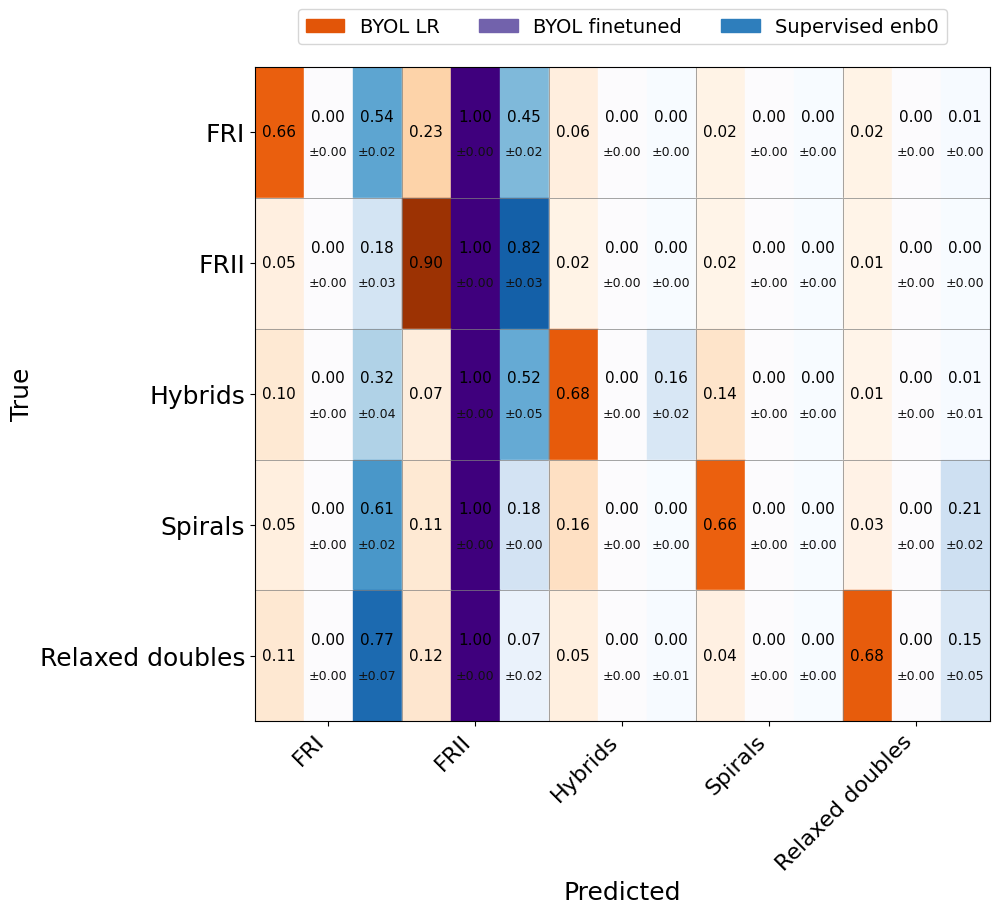

In [52]:
if y_te_byol is None:
    print("Skipping confusion matrix — BYOL predictions unavailable (see cell above).")
else:
    _class_names = [ALL_CLASS_NAMES[i] for i in LABEL_SETS[_ls]]
    n_cls = len(_class_names)

    # ── BYOL confusion matrix ─────────────────────────────────────────────────────
    cm_b   = confusion_matrix(y_te_byol, y_pred_byol, labels=list(range(n_cls)))
    cm_b_n = cm_b / cm_b.sum(axis=1, keepdims=True).clip(min=1)

    # ── Finetuning — per-run CMs for mean ± std ─────────────────────────────────
    _cw_tag_ft = f"cw{_cw}" if _cw else "cwNone"
    _es_tag    = "_ES" if CONFIG.get("early_stopping", False) else ""
    _ft_type   = f"{_tls}_{_cw_tag_ft}{_es_tag}_{CONFIG['finetuning_spec']}"
    _ft_dir    = _run_dir / "data" / "classifiers" / "finetuning" / _ft_type
    _ft_run_norms, _ft_run_metrics = [], []
    for _rp in sorted(_ft_dir.glob("run*/test_probs.npy")):
        _rl = _rp.parent / "test_labels.npy"
        if not _rl.exists():
            continue
        _p = np.load(_rp); _l = np.load(_rl)
        if _l.ndim == 2 and _l.shape[1] >= 5:
            _mask = _l[:, :5].sum(axis=1) == 1
            _p, _l = _p[_mask, :5], _l[_mask, :5]
        _yt = _l.argmax(axis=1) if _l.ndim == 2 else _l
        _yp = _p.argmax(axis=1)
        _cm_r = confusion_matrix(_yt, _yp, labels=list(range(n_cls)))
        _ft_run_norms.append(_cm_r / _cm_r.sum(axis=1, keepdims=True).clip(min=1))
        _ft_run_metrics.append({
            "F1":     f1_score(_yt, _yp, average="macro", zero_division=0),
            "AUC":    roc_auc_score(
                          label_binarize(_yt, classes=list(range(n_cls))),
                          _p, multi_class="ovr", average="macro"),
            "Acc":    accuracy_score(_yt, _yp),
            "Recall": recall_score(_yt, _yp, average="macro", zero_division=0),
        })

    if _ft_run_norms:
        cm_ft_n   = np.mean(_ft_run_norms, axis=0)
        cm_ft_std = np.std(_ft_run_norms,  axis=0) if len(_ft_run_norms) > 1 else None
        _ft_metrics = {k: (float(np.mean([m[k] for m in _ft_run_metrics])),
                           float(np.std ([m[k] for m in _ft_run_metrics]))
                           if len(_ft_run_metrics) > 1 else None)
                       for k in ("F1", "AUC", "Acc", "Recall")}
        print(f"Finetuning ({_ft_type}): {len(_ft_run_norms)} run(s)")
    else:
        cm_ft_n = cm_ft_std = None
        _ft_metrics = {}
        print(f"Finetuning: no predictions found in {_ft_dir}")

    # ── Supervised baseline ───────────────────────────────────────────────────────
    cm_s_n   = _cm_base_mean
    cm_s_std = _cm_base_std

    # ── Metrics table ─────────────────────────────────────────────────────────────
    # Prefer cross-eval JSON (tls→els); fall back to legacy name; compute inline if missing.
    if _tls_cm == _ls:
        _byol_json = _clf_dir / f"{_clf_short}_projections.json"
    else:
        _byol_json = _clf_dir / f"{_clf_short}_projections_{_ls}_eval.json"
    if not _byol_json.exists():
        _byol_json = _clf_dir / f"{_clf_short}_{_ls}_projections.json"  # legacy naming

    if _byol_json.exists():
        with open(_byol_json) as _f:
            _bj = json.load(_f)
        _byol_metrics = {
            "F1":     _bj["f1_macro"],
            "AUC":    _bj["auc_macro"],
            "Acc":    _bj["accuracy"],
            "Recall": _bj["recall_macro"],
        }
    else:
        # Compute inline from cross-eval predictions derived in cell 26
        _n_cm = len(LABEL_SETS[_ls])
        _y_bin_cm = label_binarize(y_te_byol, classes=list(range(_n_cm)))
        try:
            _auc_cm = float(roc_auc_score(_y_bin_cm, _cm_byol_probs5,
                                           multi_class="ovr", average="macro"))
        except Exception:
            _auc_cm = float("nan")
        _byol_metrics = {
            "F1":     float(f1_score(y_te_byol, y_pred_byol, average="macro", zero_division=0)),
            "AUC":    _auc_cm,
            "Acc":    float(accuracy_score(y_te_byol, y_pred_byol)),
            "Recall": float(recall_score(y_te_byol, y_pred_byol, average="macro", zero_division=0)),
        }
        print(f"Note: metrics computed from cross-eval predictions ({_byol_json.name} not found)")

    print(f"\n{'Metric':<8}  {'BYOL LR':>18}  {'Finetuned':>22}  {'Base':>18}")
    print("-" * 62)
    for k in ["F1", "AUC", "Acc", "Recall"]:
        mu_b, sd_b = _base_metrics_agg[k]
        s_base = f"{mu_b:.2f} ± {sd_b:.2f}" if sd_b is not None else f"{mu_b:.2f}"
        if _ft_metrics:
            mu_f, sd_f = _ft_metrics[k]
            s_ft = f"{mu_f:.2f} ± {sd_f:.2f}" if sd_f is not None else f"{mu_f:.2f}"
        else:
            s_ft = "N/A"
        print(f"{k:<8}  {_byol_metrics[k]:>18.2f}  {s_ft:>22}  {s_base:>18}")

    # ── Plot ──────────────────────────────────────────────────────────────────────
    cmap_b  = plt.cm.Oranges   # BYOL linear probe
    cmap_ft = plt.cm.Purples   # Finetuned
    cmap_s  = plt.cm.Blues     # Supervised baseline

    _w = 1 / 3  # width of each third

    _clf_display = {"linear_probe": "LR", "random_forest": "RF", "knn": "KNN"}.get(
        CM_CONFIG["byol_classifier"], CM_CONFIG["byol_classifier"])

    fig, ax = plt.subplots(figsize=(n_cls * 1.5 + 3, n_cls * 1.5 + 1))
    plt.subplots_adjust(left=0.28, right=0.98)
    ax.set_xlim(0, n_cls); ax.set_ylim(0, n_cls)
    ax.invert_yaxis()

    _n_runs_base = len(_base_run_norms)
    _n_runs_ft   = len(_ft_run_norms)
    for i in range(n_cls):
        for j in range(n_cls):
            # Left third — BYOL linear probe
            ax.add_patch(plt.Rectangle([j, i], _w, 1, color=cmap_b(cm_b_n[i, j])))
            ax.text(j + _w * 0.5, i + 0.5, f"{cm_b_n[i,j]:.2f}",
                    ha="center", va="center", fontsize=11)

            # Middle third — Finetuned (mean ± std)
            _ft_val = cm_ft_n[i, j] if cm_ft_n is not None else 0.0
            ax.add_patch(plt.Rectangle([j + _w, i], _w, 1, color=cmap_ft(_ft_val)))
            if cm_ft_n is not None:
                ax.text(j + _w * 1.5, i + 0.38, f"{_ft_val:.2f}",
                        ha="center", va="center", fontsize=11)
                if cm_ft_std is not None:
                    ax.text(j + _w * 1.5, i + 0.65, f"±{cm_ft_std[i,j]:.2f}",
                            ha="center", va="center", fontsize=9, color="#111111")

            # Right third — Supervised baseline (mean ± std)
            ax.add_patch(plt.Rectangle([j + 2*_w, i], _w, 1, color=cmap_s(cm_s_n[i, j])))
            ax.text(j + _w * 2.5, i + 0.38, f"{cm_s_n[i,j]:.2f}",
                    ha="center", va="center", fontsize=11)
            if cm_s_std is not None:
                ax.text(j + _w * 2.5, i + 0.65, f"±{cm_s_std[i,j]:.2f}",
                        ha="center", va="center", fontsize=9, color="#111111")

            ax.add_patch(plt.Rectangle([j, i], 1, 1, fill=False, edgecolor="grey", lw=0.5))

    ax.set_xticks(np.arange(n_cls) + 0.5)
    ax.set_xticklabels(_class_names, rotation=45, ha="right", fontsize=16)
    ax.set_yticks(np.arange(n_cls) + 0.5)
    ax.set_yticklabels(_class_names, fontsize=18)
    ax.set_xlabel("Predicted", fontsize=18)
    ax.set_ylabel("True", fontsize=18)

    ax.legend(handles=[
        mpatches.Patch(color=plt.cm.Oranges(0.7), label=f"BYOL {_clf_display}"),
        mpatches.Patch(color=plt.cm.Purples(0.7), label=f"BYOL finetuned"),
        mpatches.Patch(color=plt.cm.Blues(0.7),   label=f"Supervised {CM_CONFIG['baseline_model']}"),
    ], loc="lower center", ncol=3, fontsize=14,
       bbox_to_anchor=(0.5, 1.02), frameon=True)

    _run_name = _run_dir.name
    plt.savefig(f"{OUT_DIR}/confusion_matrix_{_run_name}_{_ls}.png", dpi=150, bbox_inches="tight")
    plt.show()


## 9. Generative Augmentation

Performance as a function of the fraction of generated images added to the training set.
The baseline (gen fraction = 0) comes from the supervised run without generative data.

Path: ../outputs/supervised_baseline_classifiers/with_generative
Found 4 gen run dir(s):
  enb0_full_cwall0.3_2607092203full_genfull
  enb0_initial_cwinitial0.3_2607092203full_geninitial
  enb0_initial_pure_cwinitial_pure0.3_2607092203full_geninitial_pure
  old

Evaluating on:    initial_pure
  frac=0 from baseline: enb0_full_cwall0.3_2607092203full_genfull
  frac=0 from baseline: enb0_initial_cwinitial0.3_2607092203full_geninitial
  frac=0 from baseline: enb0_initial_pure_cwinitial_pure0.3_2607092203full_geninitial_pure
  Skipping unrecognised dir: old

Per-dir fractions (eval on 'initial_pure', 3 run(s)):
  enb0_full_cwall0.3_2607092203full_genfull: fracs=[0.0, 0.5, 1.0, 2.0]  ls=full  cw=cwall0.3  ES=False  genls=full
  enb0_initial_cwinitial0.3_2607092203full_geninitial: fracs=[0.0, 0.5, 1.0, 2.0]  ls=initial  cw=cwinitial0.3  ES=False  genls=initial
  enb0_initial_pure_cwinitial_pure0.3_2607092203full_geninitial_pure: fracs=[0.0, 0.5, 1.0, 2.0]  ls=initial_pure  cw=cwinitial_pure0

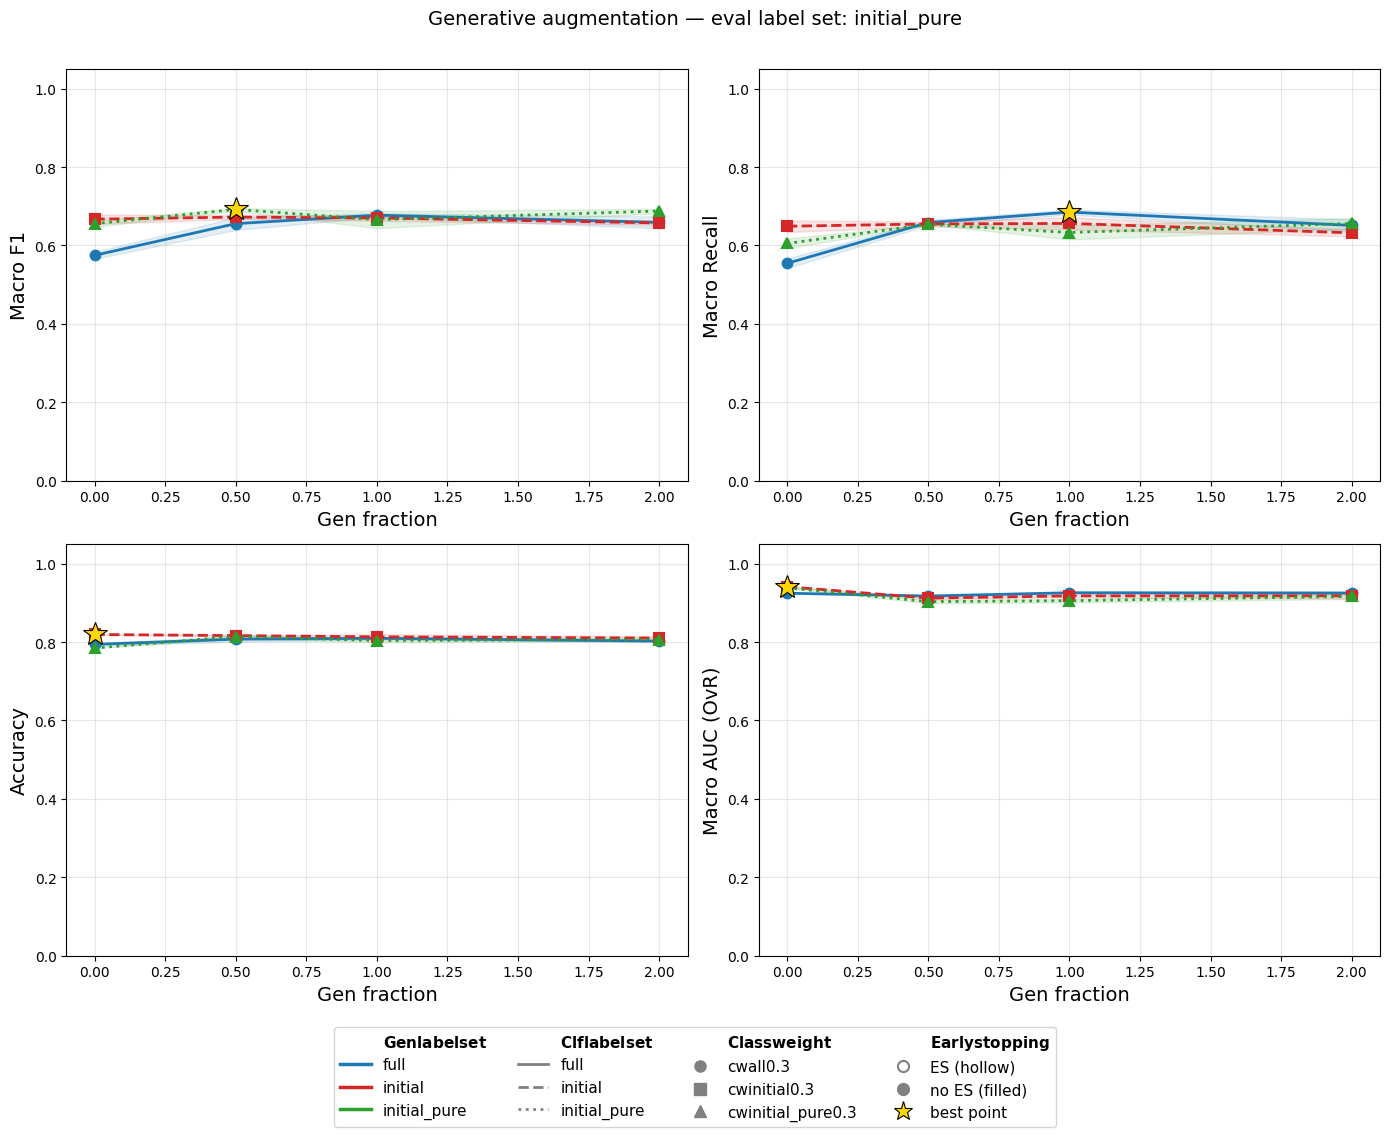

Saved → ../outputs/figures/classification/gen_aug_sweep.png


In [53]:
# ── Find all gen-aug run dirs under baselines_dir/with_generative ─────────────
_gen_basedir = Path(CONFIG["baselines_dir"]) / "with_generative"
_gen_run_dirs = sorted(
    d for d in _gen_basedir.iterdir() if d.is_dir()
) if _gen_basedir.exists() else []

print(f"Path: {_gen_basedir}")
print(f"Found {len(_gen_run_dirs)} gen run dir(s):")
for _d in _gen_run_dirs:
    print(f"  {_d.name}")

_eval_ls = CONFIG["eval_label_set"]
print(f"\nEvaluating on:    {_eval_ls}")

_GA_METRICS = [
    ("f1_macro",     "Macro F1"),
    ("recall_macro", "Macro Recall"),
    ("accuracy",     "Accuracy"),
    ("auc_macro",    "Macro AUC (OvR)"),
]
_GA_KEYS = [m for m, _ in _GA_METRICS]


def _parse_gen_dir(name):
    """Extract (ls, cw, es, genls) from gen-aug dir name."""
    m = re.match(r'enb0_(.+?)_(cw[\w.]+?)(_ES)?_\d+\w+_gen(\w+)', name)
    if m:
        return {"ls": m.group(1), "cw": m.group(2), "es": bool(m.group(3)), "genls": m.group(4)}
    return {"ls": "?", "cw": "cwNone", "es": False, "genls": "?"}


def _load_gen_frac_results(run_dir, clf_ls, eval_ls):
    """Load {gfrac: {mkey: [values]}} from a gen dir, evaluating on eval_ls.

    If clf_ls == eval_ls: reads directly from results.json.
    Otherwise: computes cross-eval from test_probs.npy + test_labels_20.npy
               (if available) and caches as results_{eval_ls}_eval.json.
    Skips silently if cross-eval is impossible (eval cols not ⊆ clf cols).
    """
    frac_dirs = list(run_dir.glob("frac_*")) or list(run_dir.glob("gen_aug/frac_*"))
    result = {}
    for _fdir in sorted(frac_dirs):
        try:
            _gf = float(_fdir.name.replace("frac_", ""))
        except ValueError:
            continue
        _bucket = result.setdefault(_gf, {mk: [] for mk in _GA_KEYS})
        for _rrun in sorted(_fdir.glob("run*")):
            _rj = _rrun / "results.json"
            if not _rj.exists():
                continue
            if clf_ls == eval_ls:
                with open(_rj) as fp:
                    r = json.load(fp)
                for mk in _GA_KEYS:
                    if mk in r:
                        _bucket[mk].append(float(r[mk]))
            else:
                # Cross-eval path
                _cache = _rrun / f"results_{eval_ls}_eval.json"
                if _cache.exists():
                    with open(_cache) as fp:
                        r = json.load(fp)
                    for mk in _GA_KEYS:
                        if mk in r:
                            _bucket[mk].append(float(r[mk]))
                else:
                    _pb_path = _rrun / "test_probs.npy"
                    _lb_path = _rrun / "test_labels_20.npy"
                    if _pb_path.exists() and _lb_path.exists():
                        try:
                            _m = _cross_eval_metrics(
                                np.load(_pb_path), np.load(_lb_path), clf_ls, eval_ls)
                            with open(_cache, "w") as fp:
                                json.dump(_m, fp, indent=2)
                            for mk in _GA_KEYS:
                                if mk in _m:
                                    _bucket[mk].append(float(_m[mk]))
                        except ValueError as _e:
                            print(f"  Skipping {_rrun.name}: {_e}")
    return result


def _baseline_frac0(gen_dir_name, clf_ls, eval_ls):
    """Read frac=0 per-run values from the matching baseline dir.

    Looks first in baselines_dir/without_generative/, then baselines_dir/ directly.
    If clf_ls != eval_ls, looks for/computes results_{eval_ls}_eval.json
    per run using test_probs.npy + test_labels_20.npy.
    Falls back to run_summary.json per_run values when clf_ls == eval_ls.
    """
    m = re.match(r'enb0_(.+?)_(cw[\w.]+?)(_ES)?_\d', gen_dir_name)
    if not m:
        return None
    ls, cwtag = m.group(1), m.group(2)
    _bbase = Path(CONFIG["baselines_dir"])
    _bl_dir = _bbase / "without_generative" / f"enb0_{ls}_{cwtag}"
    if not _bl_dir.exists():
        _bl_dir = _bbase / f"enb0_{ls}_{cwtag}"
    if not _bl_dir.exists():
        return None

    if clf_ls == eval_ls:
        # Original path: read from run_summary.json
        _rs_path = _bl_dir / "run_summary.json"
        if not _rs_path.exists():
            return None
        with open(_rs_path) as fp:
            rs = json.load(fp)
        pm = rs.get("per_metric", {})
        return {mk: pm.get(mk, {}).get("per_run", []) for mk in _GA_KEYS}
    else:
        # Cross-eval: collect per-run results from individual run dirs
        _per_run = {mk: [] for mk in _GA_KEYS}
        for _rrun in sorted(_bl_dir.glob("run*")):
            _cache = _rrun / f"results_{eval_ls}_eval.json"
            if _cache.exists():
                with open(_cache) as fp:
                    r = json.load(fp)
                for mk in _GA_KEYS:
                    if mk in r:
                        _per_run[mk].append(float(r[mk]))
            else:
                _pb_path = _rrun / "test_probs.npy"
                _lb_path = _rrun / "test_labels_20.npy"
                if _pb_path.exists() and _lb_path.exists():
                    try:
                        _m = _cross_eval_metrics(
                            np.load(_pb_path), np.load(_lb_path), clf_ls, eval_ls)
                        with open(_cache, "w") as fp:
                            json.dump(_m, fp, indent=2)
                        for mk in _GA_KEYS:
                            if mk in _m:
                                _per_run[mk].append(float(_m[mk]))
                    except ValueError:
                        pass
        return _per_run if any(_per_run.values()) else None


# ── Collect per-dir data ───────────────────────────────────────────────────────
_ga_by_dir = {}
_ga_attrs  = {}

for _grd in _gen_run_dirs:
    _attrs = _parse_gen_dir(_grd.name)
    if _attrs["ls"] == "?":
        print(f"  Skipping unrecognised dir: {_grd.name}")
        continue
    _frac_vals = _load_gen_frac_results(_grd, _attrs["ls"], _eval_ls)
    if 0.0 not in _frac_vals:
        _bl0 = _baseline_frac0(_grd.name, _attrs["ls"], _eval_ls)
        if _bl0:
            _frac_vals[0.0] = _bl0
            print(f"  frac=0 from baseline: {_grd.name}")
    if _frac_vals:
        _ga_by_dir[_grd.name] = {
            gf: {
                mk: (float(np.mean(vs)), float(np.std(vs)) if len(vs) > 1 else 0.0)
                for mk, vs in mdict.items() if vs
            }
            for gf, mdict in sorted(_frac_vals.items())
        }
        _ga_attrs[_grd.name] = _attrs

print(f"\nPer-dir fractions (eval on '{_eval_ls}', {len(_ga_by_dir)} run(s)):")
for dn, da in _ga_by_dir.items():
    a = _ga_attrs[dn]
    print(f"  {dn}: fracs={sorted(da)}  ls={a['ls']}  cw={a['cw']}  ES={a['es']}  genls={a['genls']}")

# ── Visual encoding ────────────────────────────────────────────────────────────
# Color → gen label set
_genls_vals  = sorted(set(a["genls"] for a in _ga_attrs.values()))
_GENLS_PALETTE = ["#1f77b4", "#d62728", "#2ca02c", "#9467bd", "#8c564b"]
_genls_color = {gl: _GENLS_PALETTE[i % len(_GENLS_PALETTE)] for i, gl in enumerate(_genls_vals)}

# Linestyle → classifier label set
_ls_vals  = sorted(set(a["ls"] for a in _ga_attrs.values()))
_LS_STYLES = ["-", "--", ":", "-."]
_ls_style  = {ls: _LS_STYLES[i % len(_LS_STYLES)] for i, ls in enumerate(_ls_vals)}

# Marker → class weight  |  fill → not ES (hollow if ES)
_cw_vals    = sorted(set(a["cw"] for a in _ga_attrs.values()))
_CW_MARKERS = ["o", "s", "^", "D", "v", "P"]
_cw_marker  = {cw: _CW_MARKERS[i % len(_CW_MARKERS)] for i, cw in enumerate(_cw_vals)}

# ── Plot ───────────────────────────────────────────────────────────────────────
if not _ga_by_dir:
    print("No gen-aug data found — skipping plot.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    fig.suptitle(f"Generative augmentation — eval label set: {_eval_ls}", fontsize=14, y=1.01)

    for ax, (mkey, ylabel) in zip(axes, _GA_METRICS):
        _best_val, _best_x, _best_y = -np.inf, None, None

        for dn, da in sorted(_ga_by_dir.items()):
            a   = _ga_attrs[dn]
            col = _genls_color[a["genls"]]
            ls  = _ls_style[a["ls"]]
            mk  = _cw_marker[a["cw"]]
            mfc = "none" if a["es"] else col

            xs   = sorted(da)
            ys   = [da[gf].get(mkey, (float("nan"), 0.0))[0] for gf in xs]
            errs = [da[gf].get(mkey, (float("nan"), 0.0))[1] for gf in xs]

            ax.plot(xs, ys, linestyle=ls, color=col, linewidth=2,
                    marker=mk, markersize=7,
                    markerfacecolor=mfc, markeredgecolor=col, markeredgewidth=1.5)
            ax.fill_between(xs,
                            [y - e for y, e in zip(ys, errs)],
                            [y + e for y, e in zip(ys, errs)],
                            alpha=0.12, color=col)

            for gf, y in zip(xs, ys):
                if np.isfinite(y) and y > _best_val:
                    _best_val, _best_x, _best_y = y, gf, y

        if _best_x is not None:
            ax.plot(_best_x, _best_y, "*", color="gold", markersize=18,
                    markeredgecolor="k", markeredgewidth=0.8, zorder=10)

        ax.set_xlabel("Gen fraction", fontsize=14)
        ax.set_ylabel(ylabel, fontsize=14)
        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.3)

    # ── Structured legend ──────────────────────────────────────────────────────
    _leg_groups = [
        [("header", "Gen label set")]
        + [("color", gl, _genls_color[gl]) for gl in _genls_vals],
        [("header", "Clf label set")]
        + [("ls", ls, _ls_style[ls]) for ls in _ls_vals],
        [("header", "Class weight")]
        + [("marker", cw, _cw_marker[cw]) for cw in _cw_vals],
        [("header", "Early stopping"),
         ("es", "ES (hollow)", True),
         ("es", "no ES (filled)", False),
         ("star", "best point")],
    ]
    _max_rows = max(len(g) for g in _leg_groups)
    _handles  = []
    for grp in _leg_groups:
        for entry in grp:
            if entry[0] == "header":
                _handles.append(plt.Line2D([], [], color="none", label=f"$\\bf{{{entry[1]}}}$"))
            elif entry[0] == "color":
                _handles.append(plt.Line2D([], [], color=entry[2], linewidth=2.5, label=entry[1]))
            elif entry[0] == "ls":
                _handles.append(plt.Line2D([], [], color="grey", linestyle=entry[2],
                                           linewidth=2, label=entry[1]))
            elif entry[0] == "marker":
                _handles.append(plt.Line2D([], [], color="grey", linestyle="none",
                                           marker=entry[2], markersize=8, label=entry[1]))
            elif entry[0] == "es":
                _mfc = "none" if entry[2] else "grey"
                _handles.append(plt.Line2D([], [], color="grey", linestyle="none",
                                           marker="o", markersize=8,
                                           markerfacecolor=_mfc, markeredgewidth=1.5,
                                           label=entry[1]))
            elif entry[0] == "star":
                _handles.append(plt.Line2D([], [], color="gold", linestyle="none",
                                           marker="*", markersize=14,
                                           markeredgecolor="k", markeredgewidth=0.8,
                                           label=entry[1]))
        # Pad group to _max_rows so columns align
        for _ in range(_max_rows - len(grp)):
            _handles.append(plt.Line2D([], [], color="none", label=""))

    fig.legend(handles=_handles, loc="upper center",
               ncol=4, fontsize=11, bbox_to_anchor=(0.5, 0), frameon=True)
    plt.tight_layout()
    _out = f"{OUT_DIR}/gen_aug_sweep.png"
    plt.savefig(_out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {_out}")
